# Main Analysis

Primary manuscript analyses using `data/analysis/analysis_dataset_enriched_v2.csv`.


# 1. Setup and Configuration

First, we import the necessary libraries and set up the key configuration variables for our analysis. **Please edit these variables to match your file paths and column names.**

We also load the dataset and prepare it for analysis e.g., creating a numeric version of our policy claim variable

## Install packages

In [2]:
# --- ENVIRONMENT CHECK ---
import sys
import subprocess

print(f"Python version: {sys.version.split()[0]}")

# --- REQUIRED PACKAGES ---
required = [
    "pandas", "numpy", "matplotlib", "seaborn", "ydata_profiling",
    "statsmodels", "nltk", "python-docx"
]

for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", pkg],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
        except subprocess.CalledProcessError:
            print(f"Warning: could not install '{pkg}'. Install it manually.")

# --- MATPLOTLIB BACKEND ---
%matplotlib inline
import matplotlib as mpl
print(f"Matplotlib backend: {mpl.get_backend()}")


Python version: 3.13.6
Matplotlib backend: inline


## load dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- SINGLE DATA LOAD: run this cell once before the analysis cells ---
ROOT = Path("..")
ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
CLAIM_COLUMN = "llm_policy_claim"
JOURNAL_COLUMN = "journal"
YEAR_COLUMN = "publication_year"
FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def rel_path(path: Path) -> str:
    return path.as_posix()


def load_analysis_dataset(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        data = pd.read_csv(path)
    elif path.suffix.lower() == ".json":
        data = pd.read_json(path)
    else:
        raise ValueError(f"Input file must be .csv or .json, got: {rel_path(path)}")

    required = [CLAIM_COLUMN, JOURNAL_COLUMN, YEAR_COLUMN]
    missing = [col for col in required if col not in data.columns]
    if missing:
        raise KeyError(f"Missing required columns in {rel_path(path)}: {missing}")

    print(f"Loaded {len(data):,} records from {rel_path(path)}")

    data = data.dropna(subset=[CLAIM_COLUMN]).copy()
    data[YEAR_COLUMN] = pd.to_numeric(data[YEAR_COLUMN], errors="coerce")
    data[JOURNAL_COLUMN] = data[JOURNAL_COLUMN].astype(str).str.title()
    data[CLAIM_COLUMN] = data[CLAIM_COLUMN].astype(bool)
    data["claim"] = data[CLAIM_COLUMN].astype(int)

    print(f"Analytic rows after dropping missing {CLAIM_COLUMN}: {len(data):,}")
    print("Claim counts:\n" + data[CLAIM_COLUMN].value_counts(dropna=False).to_string())
    if "design_combined" in data.columns:
        n_design = int(data["design_combined"].ne("Other/None").sum())
        print(f"Rows with design_combined != Other/None: {n_design:,}")

    return data.reset_index(drop=True)


analysis_df = load_analysis_dataset(ANALYSIS_DATA_FILE)
df = analysis_df.copy()
df.head()


Loaded 45,807 records from ../data/analysis/analysis_dataset_enriched_v2.csv
Analytic rows after dropping missing llm_policy_claim: 45,807
Claim counts:
llm_policy_claim
False    34072
True     11735
Rows with design_combined != Other/None: 15,075


,scopus_id,doi,title,journal,publication_year,keywords,abstract,article_type,corresponding_author_country,cited_by_count,...,design_abstract,design_strict,design_keywords,design_combined,design_combined_unambiguous,is_methodological,is_excluded_sensitivity,is_policy_analysis_eval,is_methods_qe,bold_policy_claim
0,SCOPUS_ID:0025248647,NaN,"Epidemic dengue 1 in Brazil, 1986: Evaluation ...",American Journal Of Epidemiology,1990,Dengue; Enzyme-linked immunosorbent assay; Epi...,"In the last 15 years, dengue fever has emerged...",article,UNITED STATES,61,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
1,SCOPUS_ID:0025695891,10.1093/oxfordjournals.aje.a115759,The validity of questionnaire reports of a his...,American Journal Of Epidemiology,1990,Epidemiologic methods; Otitis media; Questionn...,"A random sample of 2,512 children with an esti...",article,FINLAND,53,...,Other/None,Other/None,Other/None,Other/None,Other/None,True,True,False,True,False
2,SCOPUS_ID:0025695889,10.1093/oxfordjournals.aje.a115751,The relation between body mass index and plasm...,American Journal Of Epidemiology,1990,Body weight; Child; Cholesterol; Chronic disea...,The relation between body mass index expressed...,article,UNITED STATES,36,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
3,SCOPUS_ID:0025690158,10.1093/oxfordjournals.aje.a115757,The strong heart study a study of cardiovascul...,American Journal Of Epidemiology,1990,"Cardiovascular disease; Indians, North America...",Available data indicate that cardiovascular di...,article,UNITED STATES,528,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
4,SCOPUS_ID:0025681563,10.1093/oxfordjournals.aje.a115761,The effects of measurement errors on relatwe r...,American Journal Of Epidemiology,1990,Regression analysis; Risk; Statistics,This paper concerns the effects of random erro...,article,CANADA,204,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False


## Create sharable dataset 

In [4]:
import pandas as pd
from pathlib import Path
import re

# Output; input is the centrally loaded df from the first setup cell.
if "analysis_df" not in globals():
    raise RuntimeError("Run the first setup cell before exporting the minimal dataset.")

df = analysis_df.copy()
print(f"Export source: {rel_path(ANALYSIS_DATA_FILE)}")

EXPORT_DIR = Path("../derived_data")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_FILE = EXPORT_DIR / "policy_claims_minimal.csv"

# Expected columns (exact names, as provided)
EXPECTED_COLS = [
    "scopus_id",
    "doi",
    "title",
    "journal",
    "publication_year",
    "keywords",
    "abstract",
    "article_type",
    "corresponding_author_country",
    "cited_by_count",
    "llm_policy_claim",
]

# Quick sanity check
missing = [c for c in EXPECTED_COLS if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

# Select the fields we will publish (no abstracts given scopus restrictions)
out = df[[
    "doi",
    "title",
    "journal",
    "publication_year",
    "keywords",  
    "corresponding_author_country",
    "llm_policy_claim",
    "design_combined",
]].copy()

# --- Minimal cleaning --- #

# DOI: normalize (lowercase, strip doi.org prefix)
out["doi"] = (
    out["doi"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"^https?://(dx\.)?doi\.org/", "", regex=True)
)

# Title/Journal trim whitespace; title left as-is (no case mangling)
for col in ["title", "journal", "corresponding_author_country"]:
    out[col] = out[col].astype(str).str.strip()

# Year: numeric (nullable int)
out["publication_year"] = pd.to_numeric(out["publication_year"], errors="coerce").astype("Int64")

# Claim: cast to binary int (0/1)
out["llm_policy_claim"] = out["llm_policy_claim"].astype(bool)

# Keywords: if list-like, join; otherwise keep string (strip)
def _norm_keywords(x):
    if isinstance(x, (list, tuple, set)):
        return "; ".join(map(str, x))
    s = None if pd.isna(x) else str(x).strip()
    return s if s else None

out["keywords"] = out["keywords"].apply(_norm_keywords)

# Drop rows missing essential fields, and deduplicate by DOI
before = len(out)
out = out.dropna(subset=["doi", "title"]).query("doi != ''").drop_duplicates(subset=["doi"]).reset_index(drop=True)
after = len(out)

print(f"Export rows: {after} (dropped {before - after} empty/duplicate DOI rows).")
print("llm_policy_claim counts:\n", out["llm_policy_claim"].value_counts(dropna=False))
if out["publication_year"].notna().any():
    print("Year range:", int(out["publication_year"].min()), "→", int(out["publication_year"].max()))

# Write
out.to_csv(EXPORT_FILE, index=False)
print(f"Wrote: {rel_path(EXPORT_FILE)}")


Export source: ../data/analysis/analysis_dataset_enriched_v2.csv
Export rows: 45722 (dropped 85 empty/duplicate DOI rows).
llm_policy_claim counts:
 llm_policy_claim
False    33998
True     11724
Name: count, dtype: int64
Year range: 1990 → 2024
Wrote: ../derived_data/policy_claims_minimal.csv


## Sense checks: cross-tabs by year and journal

In [5]:
#simple cross-tabs, by year and journal.... 
# Percent policy claim by year
year_pct = df.groupby('publication_year')['llm_policy_claim'].mean() * 100
print(year_pct)

# Percent policy claim by journal
journal_pct = df.groupby('journal')['llm_policy_claim'].mean() * 100
print(journal_pct)

publication_year
1990    12.529002
1991    16.831683
1992    13.807531
1993    19.194062
1994    18.492462
1995    17.913386
1996    18.333333
1997    17.709180
1998    19.915612
1999    19.777601
2000    19.781079
2001    20.093095
2002    19.519833
2003    21.190893
2004    23.592085
2005    23.298639
2006    23.184818
2007    23.732550
2008    23.606811
2009    28.332170
2010    27.233429
2011    24.826147
2012    26.134056
2013    28.156491
2014    25.160163
2015    28.199189
2016    27.449514
2017    32.168285
2018    32.318210
2019    32.163743
2020    34.909910
2021    36.384705
2022    36.730889
2023    34.557235
2024    36.232980
Name: llm_policy_claim, dtype: float64
journal
American Journal Of Epidemiology                 9.892744
American Journal Of Preventive Medicine         38.145721
American Journal Of Public Health               33.674907
Epidemiology                                     3.683536
European Journal Of Epidemiology                14.397906
European Journal

In [6]:
# Tabulate % True, False, and missing for a column - note n=1 is missing
col = 'llm_policy_claim'
tab = df[col].value_counts(dropna=False, normalize=False) 
print(tab)

llm_policy_claim
False    34072
True     11735
Name: count, dtype: int64


# Confirm sample size / analytical N

In [7]:
# 1) Overall analytic N you expect vs. what Table 1 sees
print("Total rows:", len(df))
print("Rows with non-missing publication_year:", df['publication_year'].notna().sum())

# 2) Non-numeric or malformed years
tmp = pd.to_numeric(df['publication_year'], errors='coerce')
print("Non-numeric/malformed years:", (tmp.isna() & df['publication_year'].notna()).sum())

# 3) Years outside your window
print("Years outside 1990–2024:", ((tmp < 1990) | (tmp > 2024)).sum())

# 4) Rows with missing abstracts
print("Rows with missing abstracts:", df['abstract'].isna().sum())

Total rows: 45807
Rows with non-missing publication_year: 45807
Non-numeric/malformed years: 0
Years outside 1990–2024: 0
Rows with missing abstracts: 0


## double check filtering from raw json-> csv worked (removal of reviews, empty abstracts etc)

In [8]:
import importlib.util
from pathlib import Path
import pandas as pd
import re

script = Path("./2_filter_records.py")
assert script.exists(), f"Not found: {script.as_posix()}"
spec = importlib.util.spec_from_file_location("filter_records", script)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

in_dir = Path("../data/json_files")
files = sorted(in_dir.glob("*.json"))
if not files:
    # Fall back to the combined filtered file when raw journal files are absent
    fallback = in_dir / "filtered" / "all_abstracts.json"
    assert fallback.exists(), f"No raw JSON files in {in_dir} and no fallback at {fallback}"
    print(f"No raw JSON files found; loading combined file: {fallback}")
    files = [fallback]

records = []
for p in files:
    records.extend(mod.load_json(p))

df_raw = pd.DataFrame.from_records(records)
print("Raw records:", len(df_raw))

kept, dropped, counts = mod.filter_df(df_raw)
print("Kept after content filters:", len(kept))          # expect 45808
print("Dropped:", len(dropped))                           # expect 4725
print("Exclusion reasons:", dict(counts))

# Optional year window 1990-2024 
YEAR = "publication_year"
kept[YEAR] = pd.to_numeric(kept[YEAR], errors="coerce")
kept = kept[(kept[YEAR] >= 1990) & (kept[YEAR] <= 2024)].copy()
print("Kept after year window:", len(kept))

labels_path = Path("../data/json_files/filtered/all_abstracts_LLM.csv")
lab = pd.read_csv(labels_path, usecols=["scopus_id", "doi", "llm_policy_claim"])

# Prepare deduped lookups
lab_scopus = lab.dropna(subset=["scopus_id"]).drop_duplicates(subset=["scopus_id"])
lab_doi    = lab.dropna(subset=["doi"]).drop_duplicates(subset=["doi"])

# Merge on scopus_id first
kept_labeled = kept.merge(
    lab_scopus[["scopus_id", "llm_policy_claim"]],
    how="left",
    on="scopus_id"
)

# Fill remaining missing labels using DOI
mask_unlabeled = kept_labeled["llm_policy_claim"].isna()
if mask_unlabeled.any():
    kept_labeled = kept_labeled.merge(
        lab_doi[["doi", "llm_policy_claim"]].rename(columns={"llm_policy_claim": "llm_policy_claim_doi"}),
        how="left",
        on="doi"
    )
    kept_labeled.loc[mask_unlabeled, "llm_policy_claim"] = kept_labeled.loc[mask_unlabeled, "llm_policy_claim_doi"]
    kept_labeled.drop(columns=["llm_policy_claim_doi"], inplace=True, errors="ignore")

print("Missing LLM label after merge:", kept_labeled["llm_policy_claim"].isna().sum())

# Validation cross-check (does not replace df loaded from enriched CSV)
df_validation = kept_labeled[kept_labeled["llm_policy_claim"].notna()].copy().reset_index(drop=True)
print("Analytical N (after dropping unlabeled):", len(df_validation))  # expect 45807

print("Rows with non-missing publication_year:", df_validation['publication_year'].notna().sum())
tmp_year = pd.to_numeric(df_validation['publication_year'], errors='coerce')
print("Years outside 1990–2024:", ((tmp_year < 1990) | (tmp_year > 2024)).sum())
print("Rows with missing abstracts:", df_validation['abstract'].isna().sum())


Raw records: 50533
Kept after content filters: 45808
Dropped: 4725
Exclusion reasons: {'empty_abs': 3108, 'abs_commentary': 250, 'review_term': 974, 'title_commentary': 393}
Kept after year window: 45808
Missing LLM label after merge: 1
Analytical N (after dropping unlabeled): 45807
Rows with non-missing publication_year: 45807
Years outside 1990–2024: 0
Rows with missing abstracts: 0


In [9]:
def mk_key(x):
    doi = x.get("doi", pd.Series("", index=x.index)).astype(str).str.lower().str.strip() \
           .str.replace(r"^https?://(dx\.)?doi\.org/", "", regex=True)
    yr  = pd.to_numeric(x.get("publication_year", np.nan), errors="coerce").fillna(-1).astype(int).astype(str)
    ttl = x.get("title",  pd.Series("", index=x.index)).astype(str).str.lower().str.strip()
    jnl = x.get("journal",pd.Series("", index=x.index)).astype(str).str.lower().str.strip()
    return doi.where(doi.ne("") & doi.ne("nan"), ttl + "|" + jnl + "|" + yr)

k = kept.assign(__key=mk_key(kept))
d = df.assign(__key=mk_key(df))

miss = (
    k.merge(d[["__key"]].drop_duplicates(), on="__key", how="left", indicator=True)
     .query("_merge == 'left_only'")
)

cols = [c for c in ["scopus_id","doi","title","journal","publication_year"] if c in miss.columns]
print(miss[cols].to_string(index=False))

           scopus_id                                doi                                                                                                                                   title                          journal  publication_year
SCOPUS_ID:0031474246 10.1093/oxfordjournals.aje.a009240 High rates of HIV infection among injection drug users participating in needle exchange programs in Montreal: Results of a cohort study American Journal of Epidemiology              1997


In [10]:
doi = "10.1093/oxfordjournals.aje.a009240"

def norm_doi(s):
    return (s.astype(str).str.strip().str.lower()
            .str.replace(r"^https?://(dx\.)?doi\.org/", "", regex=True))

llm = pd.read_csv("../data/json_files/filtered/all_abstracts_LLM.csv")
llm["doi_norm"] = norm_doi(llm.get("doi", pd.Series(index=llm.index)))

row = llm.loc[llm["doi_norm"].eq(doi), ["doi","journal","publication_year","llm_policy_claim"]]
print(row if not row.empty else "DOI not present in LLM file")

# Confirm it is missing from df after you dropped NaNs in llm_policy_claim
d = df.assign(doi_norm=norm_doi(df.get("doi", pd.Series(index=df.index))))
print("In df:", d["doi_norm"].eq(doi).any())

                                     doi                           journal  \
1720  10.1093/oxfordjournals.aje.a009240  American Journal of Epidemiology   

      publication_year llm_policy_claim  
1720              1997              NaN  
In df: False


## Sense check: journal names and corresponding author countries

In [11]:
# sense check: Check unique journal names and count - in case of spelling inconsistencies. should be n=10 journals
print('JOURNAL_COLUMN variable:', JOURNAL_COLUMN)
print('Unique journal names in DataFrame:')
print(df[JOURNAL_COLUMN].unique())
print('Number of unique journals:', df[JOURNAL_COLUMN].nunique())

# New: Inspect and standardize corresponding_author_country
print('\n--- Corresponding author country check ---')
if 'corresponding_author_country' in df.columns:
    # Raw counts as DataFrame with column named 'N'
    raw_counts = df['corresponding_author_country'].value_counts(dropna=False)
    raw_counts_df = raw_counts.reset_index().rename(columns={'index': 'country', 'corresponding_author_country': 'N'})
    print('Value counts (raw):')
    print(raw_counts_df.head(50).to_string(index=False))

    # Standardize: strip whitespace, convert to upper case, treat empty strings and nulls as UNKNOWN
    df['corresponding_author_country'] = (
        df['corresponding_author_country']
        .astype(str)
        .str.strip()
        .replace({'nan': None})
    )
    df['corresponding_author_country'] = (
        df['corresponding_author_country']
        .fillna('UNKNOWN')
        .replace({'': 'UNKNOWN'})
        .str.upper()
    )

    # Standardized counts as DataFrame with column 'N'
    std_counts = df['corresponding_author_country'].value_counts()
    std_counts_df = std_counts.reset_index().rename(columns={'index': 'country', 'corresponding_author_country': 'N'})
    print('\nAfter standardization:')
    print(std_counts_df.head(50).to_string(index=False))

    # Number of unique countries
    print('\nNumber of unique countries (N):', df['corresponding_author_country'].nunique())
else:
    print('Column "corresponding_author_country" not found in dataframe')

JOURNAL_COLUMN variable: journal
Unique journal names in DataFrame:
['American Journal Of Epidemiology'
 'American Journal Of Preventive Medicine'
 'American Journal Of Public Health' 'Epidemiology'
 'European Journal Of Epidemiology' 'European Journal Of Public Health'
 'International Journal Of Epidemiology'
 'Journal Of Epidemiology And Community Health' 'The Lancet Public Health'
 'Preventive Medicine']
Number of unique journals: 10

--- Corresponding author country check ---
Value counts (raw):
                 N  count
     UNITED STATES  23417
    UNITED KINGDOM   4033
            CANADA   1665
       NETHERLANDS   1608
         AUSTRALIA   1370
            SWEDEN   1201
            FRANCE   1108
             SPAIN    998
           DENMARK    965
           FINLAND    936
             ITALY    895
           GERMANY    740
             CHINA    718
             JAPAN    613
            NORWAY    610
           UNKNOWN    356
       SWITZERLAND    348
           BELGIUM    284
 

# Main analysis

## Table 1: Key Characteristics of the Dataset

This table provides a high-level summary of the entire dataset, including the total number of articles, the overall rate of policy claims, and the diversity of journals and countries represented.

In [12]:
# Reuse the dataset loaded in the first setup cell. No file is read here.
if "analysis_df" not in globals():
    raise RuntimeError("Run the first setup cell before this section so analysis_df is available.")

df = analysis_df.copy()
print(f"Using centrally loaded data: {rel_path(ANALYSIS_DATA_FILE)}")
print(f"Rows available: {len(df):,}")
df.head()


Using centrally loaded data: ../data/analysis/analysis_dataset_enriched_v2.csv
Rows available: 45,807


,scopus_id,doi,title,journal,publication_year,keywords,abstract,article_type,corresponding_author_country,cited_by_count,...,design_abstract,design_strict,design_keywords,design_combined,design_combined_unambiguous,is_methodological,is_excluded_sensitivity,is_policy_analysis_eval,is_methods_qe,bold_policy_claim
0,SCOPUS_ID:0025248647,NaN,"Epidemic dengue 1 in Brazil, 1986: Evaluation ...",American Journal Of Epidemiology,1990,Dengue; Enzyme-linked immunosorbent assay; Epi...,"In the last 15 years, dengue fever has emerged...",article,UNITED STATES,61,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
1,SCOPUS_ID:0025695891,10.1093/oxfordjournals.aje.a115759,The validity of questionnaire reports of a his...,American Journal Of Epidemiology,1990,Epidemiologic methods; Otitis media; Questionn...,"A random sample of 2,512 children with an esti...",article,FINLAND,53,...,Other/None,Other/None,Other/None,Other/None,Other/None,True,True,False,True,False
2,SCOPUS_ID:0025695889,10.1093/oxfordjournals.aje.a115751,The relation between body mass index and plasm...,American Journal Of Epidemiology,1990,Body weight; Child; Cholesterol; Chronic disea...,The relation between body mass index expressed...,article,UNITED STATES,36,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
3,SCOPUS_ID:0025690158,10.1093/oxfordjournals.aje.a115757,The strong heart study a study of cardiovascul...,American Journal Of Epidemiology,1990,"Cardiovascular disease; Indians, North America...",Available data indicate that cardiovascular di...,article,UNITED STATES,528,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
4,SCOPUS_ID:0025681563,10.1093/oxfordjournals.aje.a115761,The effects of measurement errors on relatwe r...,American Journal Of Epidemiology,1990,Regression analysis; Risk; Statistics,This paper concerns the effects of random erro...,article,CANADA,204,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False


*Table 1. Characteristics of Epidemiology/Public Health abstracts: policy claims by year, journal, and country*

In [13]:
import pandas as pd
import numpy as np

# Define time periods with accurate labels
periods = {
    '1990-1999': (1990, 2000),
    '2000-2009': (2000, 2010),
    '2010-2019': (2010, 2020),
    '2020-2024': (2020, 2025),
    'All years': (1990, 2025)
}

# Get top 10 journals by article count
top_10_journals = df['journal'].value_counts().head(10).index.tolist()

# Calculate policy claim rates for 2020-2024 to sort journals
period_2020_df = df[(df['publication_year'] >= 2020) & (df['publication_year'] < 2025)]
journal_policy_rates = {}

for journal in top_10_journals:
    journal_df = period_2020_df[period_2020_df['journal'] == journal]
    n_journal_articles = len(journal_df)
    
    if n_journal_articles > 0:
        journal_policy_claims = (journal_df['claim'] == 1).sum()
        pct_journal_policy = (journal_policy_claims / n_journal_articles * 100)
        journal_policy_rates[journal] = pct_journal_policy
    else:
        journal_policy_rates[journal] = 0

# Sort journals by policy claim rate (ascending, so lowest first, highest last)
sorted_journals = sorted(journal_policy_rates.keys(), key=lambda x: journal_policy_rates[x])

# Get top 15 countries by publication count
top_15_countries = df['corresponding_author_country'].value_counts().head(15).index.tolist()

# Calculate policy claim rates for 2020-2024 to sort countries
country_policy_rates = {}

for country in top_15_countries:
    country_df = period_2020_df[period_2020_df['corresponding_author_country'] == country]
    n_country_articles = len(country_df)
    
    if n_country_articles > 0:
        country_policy_claims = (country_df['claim'] == 1).sum()
        pct_country_policy = (country_policy_claims / n_country_articles * 100)
        country_policy_rates[country] = pct_country_policy
    else:
        country_policy_rates[country] = 0

# Sort countries by policy claim rate (ascending, so lowest first, highest last)
sorted_countries = sorted(country_policy_rates.keys(), key=lambda x: country_policy_rates[x])

# Initialize results dictionary
results = {}
row_names = []
categories = []

# Metrics to calculate
metrics = [
    'Number of articles, N',
    'Number of unique journals, N',
    'Words in abstracts, mean (SD)',
    'Papers with keywords included, %',
    'Countries of corresponding author, N',
    'Policy claims, N (%)'
]

# Initialize results structure for base metrics
for metric in metrics:
    results[metric] = {}
    row_names.append(metric)
    categories.append('')

# Add "All journals/countries" row
results['  All journals/countries'] = {}
row_names.append('  All journals/countries')
categories.append('')

# Add journal heading
results['Journals, policy claim rate (%)'] = {}
row_names.append('Journals, policy claim rate (%)')
categories.append('Journal')

# Initialize results structure for journal-specific metrics (in sorted order)
for i, journal in enumerate(sorted_journals):
    results[f'  {journal}'] = {}
    row_names.append(f'  {journal}')
    categories.append('Journal')

# Add country heading
results['Countries (first author), policy claim rate (%)'] = {}
row_names.append('Countries (first author), policy claim rate (%)')
categories.append('Country')

# Initialize results structure for country-specific metrics (in sorted order)
for i, country in enumerate(sorted_countries):
    # Format country name: capitalize first letter only
    country_formatted = country.capitalize() if isinstance(country, str) else country
    results[f'  {country_formatted}'] = {}
    row_names.append(f'  {country_formatted}')
    categories.append('Country')

# Calculate metrics for each period
for period_name, (start_year, end_year) in periods.items():
    # Filter data for the period
    period_df = df[(df['publication_year'] >= start_year) & (df['publication_year'] < end_year)]
    
    # Number of articles
    n_articles = len(period_df)
    results['Number of articles, N'][period_name] = n_articles
    
    # Number of unique journals
    results['Number of unique journals, N'][period_name] = period_df['journal'].nunique()
    
    # Words in abstracts - calculate word count for each abstract
    word_counts = period_df['abstract'].fillna('').str.split().str.len()
    mean_words = word_counts.mean()
    sd_words = word_counts.std()
    results['Words in abstracts, mean (SD)'][period_name] = f"{mean_words:.1f} ({sd_words:.1f})" if not pd.isna(mean_words) else "N/A"
    
    # Papers with keywords included (not null, not empty list, not empty string)
    def has_keywords(x):
        if pd.isna(x):
            return False
        if isinstance(x, list) and len(x) == 0:
            return False
        if isinstance(x, str) and (x.strip() == '' or x.strip() == '[]'):
            return False
        return True
    
    papers_with_keywords = period_df['keywords'].apply(has_keywords).sum()
    pct_with_keywords = (papers_with_keywords / n_articles * 100) if n_articles > 0 else 0
    results['Papers with keywords included, %'][period_name] = f"{pct_with_keywords:.1f}"
    
    # Countries of corresponding author - count unique countries
    results['Countries of corresponding author, N'][period_name] = period_df['corresponding_author_country'].nunique()
    
    # Policy claims - count papers where claim == 1
    papers_with_policy = (period_df['claim'] == 1).sum()
    pct_policy = (papers_with_policy / n_articles * 100) if n_articles > 0 else 0
    results['Policy claims, N (%)'][period_name] = f"{papers_with_policy} ({pct_policy:.1f})"
    
    # All journals/countries % policy claims
    results['  All journals/countries'][period_name] = f"{pct_policy:.1f}"
    
    # Journal heading (empty)
    results['Journals, policy claim rate (%)'][period_name] = ""
    
    # Calculate policy claim percentages for each of the top 10 journals (in sorted order)
    for journal in sorted_journals:
        journal_df = period_df[period_df['journal'] == journal]
        n_journal_articles = len(journal_df)
        
        if n_journal_articles > 0:
            journal_policy_claims = (journal_df['claim'] == 1).sum()
            pct_journal_policy = (journal_policy_claims / n_journal_articles * 100)
            results[f'  {journal}'][period_name] = f"{pct_journal_policy:.1f}"
        else:
            results[f'  {journal}'][period_name] = "N/A"
    
    # Country heading (empty)
    results['Countries (first author), policy claim rate (%)'][period_name] = ""
    
    # Calculate policy claim percentages for each of the top 15 countries (in sorted order)
    for country in sorted_countries:
        country_df = period_df[period_df['corresponding_author_country'] == country]
        n_country_articles = len(country_df)
        
        # Format country name: capitalize first letter only
        country_formatted = country.capitalize() if isinstance(country, str) else country
        
        if n_country_articles > 0:
            country_policy_claims = (country_df['claim'] == 1).sum()
            pct_country_policy = (country_policy_claims / n_country_articles * 100)
            results[f'  {country_formatted}'][period_name] = f"{pct_country_policy:.1f}"
        else:
            results[f'  {country_formatted}'][period_name] = "N/A"

# Create the table with correct orientation (metrics as rows, periods as columns)
table1 = pd.DataFrame(results).T

# Rename the index to remove the default "name" label
table1.index.name = None

# Create a styled version for display in Jupyter
from IPython.display import HTML

# Create HTML table with bold for Journals and Countries rows
def format_table_html(table_df, row_names):
    html = "<table border='1' cellpadding='8'><tr>"
    
    # Header row
    html += "<th></th>"
    for col in table_df.columns:
        html += f"<th>{col}</th>"
    html += "</tr>"
    
    # Data rows
    for i, row_name in enumerate(row_names):
        if row_name in [
    'Journals, policy claim rate (%)',
    'Countries (first author), policy claim rate (%)'
]:
            html += f"<tr><td><b>{row_name}</b></td>"
        else:
            html += f"<tr><td>{row_name}</td>"
        
        for col in table_df.columns:
            html += f"<td>{table_df.loc[row_names[i], col]}</td>"
        html += "</tr>"
    
    html += "</table>"
    return html

# Display the table
print("\nTable 1: Descriptive Statistics by Time Period")
print("="*120)
print(table1.to_string())

# Also display as formatted HTML in Jupyter
display(HTML(format_table_html(table1, row_names)))


Table 1: Descriptive Statistics by Time Period
                                                    1990-1999     2000-2009     2010-2019     2020-2024     All years
Number of articles, N                                   10436         12529         15464          7378         45807
Number of unique journals, N                                9             9            10            10            10
Words in abstracts, mean (SD)                    205.5 (67.5)  215.9 (55.2)  221.0 (52.0)  238.4 (57.4)  218.9 (58.5)
Papers with keywords included, %                         49.4          60.6          45.1          57.8          52.4
Countries of corresponding author, N                      113           119           122           104           154
Policy claims, N (%)                              1841 (17.6)   2857 (22.8)   4394 (28.4)   2643 (35.8)  11735 (25.6)
  All journals/countries                                 17.6          22.8          28.4          35.8          25.6
Journals

,1990-1999,2000-2009,2010-2019,2020-2024,All years
"Number of articles, N",10436,12529,15464,7378,45807
"Number of unique journals, N",9,9,10,10,10
"Words in abstracts, mean (SD)",205.5 (67.5),215.9 (55.2),221.0 (52.0),238.4 (57.4),218.9 (58.5)
"Papers with keywords included, %",49.4,60.6,45.1,57.8,52.4
"Countries of corresponding author, N",113,119,122,104,154
"Policy claims, N (%)",1841 (17.6),2857 (22.8),4394 (28.4),2643 (35.8),11735 (25.6)
All journals/countries,17.6,22.8,28.4,35.8,25.6
"Journals, policy claim rate (%)",,,,,
Epidemiology,1.2,4.1,4.5,5.3,3.7
European Journal Of Epidemiology,19.4,15.3,10.0,14.3,14.4


### export table 1

In [14]:
# CSV file
import csv
cols = ['1990-1999','2000-2009','2010-2019','2020-2024','All years']
cols = [x for x in cols if x in table1.columns] + [x for x in table1.columns if x not in cols]
t = table1.copy()
t.insert(0, 'Row', t.index)
with open('../table/table1_descriptive_stats.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Row'] + cols)
    w.writerows(t[['Row'] + cols].to_numpy())

In [15]:
# Docs file
from docx import Document
from docx.shared import Inches
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH

cols = ['All years','1990-1999','2000-2009','2010-2019','2020-2024']
cols = [c for c in col if c in table1.columns] + [c for c in table1.columns if c not in col]
docx_df = table1.loc[[r for r in row_names if r in table1.index], cols].copy()
docx_df.insert(0, "Row", docx_df.index)

doc = Document()
t = doc.add_table(rows=1, cols=len(docx_df.columns), style="Table Grid")
t.alignment = WD_TABLE_ALIGNMENT.CENTER
for j,c in enumerate(docx_df.columns): t.rows[0].cells[j].paragraphs[0].add_run(str(c)).bold=True

for i in range(len(docx_df)):
    cells = t.add_row().cells
    for j,c in enumerate(docx_df.columns):
        val = "" if pd.isna(docx_df.iat[i,j]) else str(docx_df.iat[i,j])
        p = cells[j].paragraphs[0]; r = p.add_run(val)
        if j==0:
            if val.strip() in ("Journals, policy claim rate (%)","Countries (first author), policy claim rate (%)"): r.bold=True
            if val.startswith("  "): p.paragraph_format.left_indent = Inches(0.25)
            p.alignment = WD_ALIGN_PARAGRAPH.LEFT
        else:
            p.alignment = WD_ALIGN_PARAGRAPH.RIGHT

doc.save("../table/table1_descriptive_stats.docx")

## Fig 1: Policy claim share over time (overall)

In [16]:
# Reuse the dataset loaded in the first setup cell. No file is read here.
if "analysis_df" not in globals():
    raise RuntimeError("Run the first setup cell before this section so analysis_df is available.")

df = analysis_df.copy()
print(f"Using centrally loaded data: {rel_path(ANALYSIS_DATA_FILE)}")
print(f"Rows available: {len(df):,}")
df.head()


Using centrally loaded data: ../data/analysis/analysis_dataset_enriched_v2.csv
Rows available: 45,807


,scopus_id,doi,title,journal,publication_year,keywords,abstract,article_type,corresponding_author_country,cited_by_count,...,design_abstract,design_strict,design_keywords,design_combined,design_combined_unambiguous,is_methodological,is_excluded_sensitivity,is_policy_analysis_eval,is_methods_qe,bold_policy_claim
0,SCOPUS_ID:0025248647,NaN,"Epidemic dengue 1 in Brazil, 1986: Evaluation ...",American Journal Of Epidemiology,1990,Dengue; Enzyme-linked immunosorbent assay; Epi...,"In the last 15 years, dengue fever has emerged...",article,UNITED STATES,61,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
1,SCOPUS_ID:0025695891,10.1093/oxfordjournals.aje.a115759,The validity of questionnaire reports of a his...,American Journal Of Epidemiology,1990,Epidemiologic methods; Otitis media; Questionn...,"A random sample of 2,512 children with an esti...",article,FINLAND,53,...,Other/None,Other/None,Other/None,Other/None,Other/None,True,True,False,True,False
2,SCOPUS_ID:0025695889,10.1093/oxfordjournals.aje.a115751,The relation between body mass index and plasm...,American Journal Of Epidemiology,1990,Body weight; Child; Cholesterol; Chronic disea...,The relation between body mass index expressed...,article,UNITED STATES,36,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
3,SCOPUS_ID:0025690158,10.1093/oxfordjournals.aje.a115757,The strong heart study a study of cardiovascul...,American Journal Of Epidemiology,1990,"Cardiovascular disease; Indians, North America...",Available data indicate that cardiovascular di...,article,UNITED STATES,528,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
4,SCOPUS_ID:0025681563,10.1093/oxfordjournals.aje.a115761,The effects of measurement errors on relatwe r...,American Journal Of Epidemiology,1990,Regression analysis; Risk; Statistics,This paper concerns the effects of random erro...,article,CANADA,204,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False


*Figure 1. Share of abstracts with policy claims in Epidemiology/Public Health Abstracts, 1990–2024*

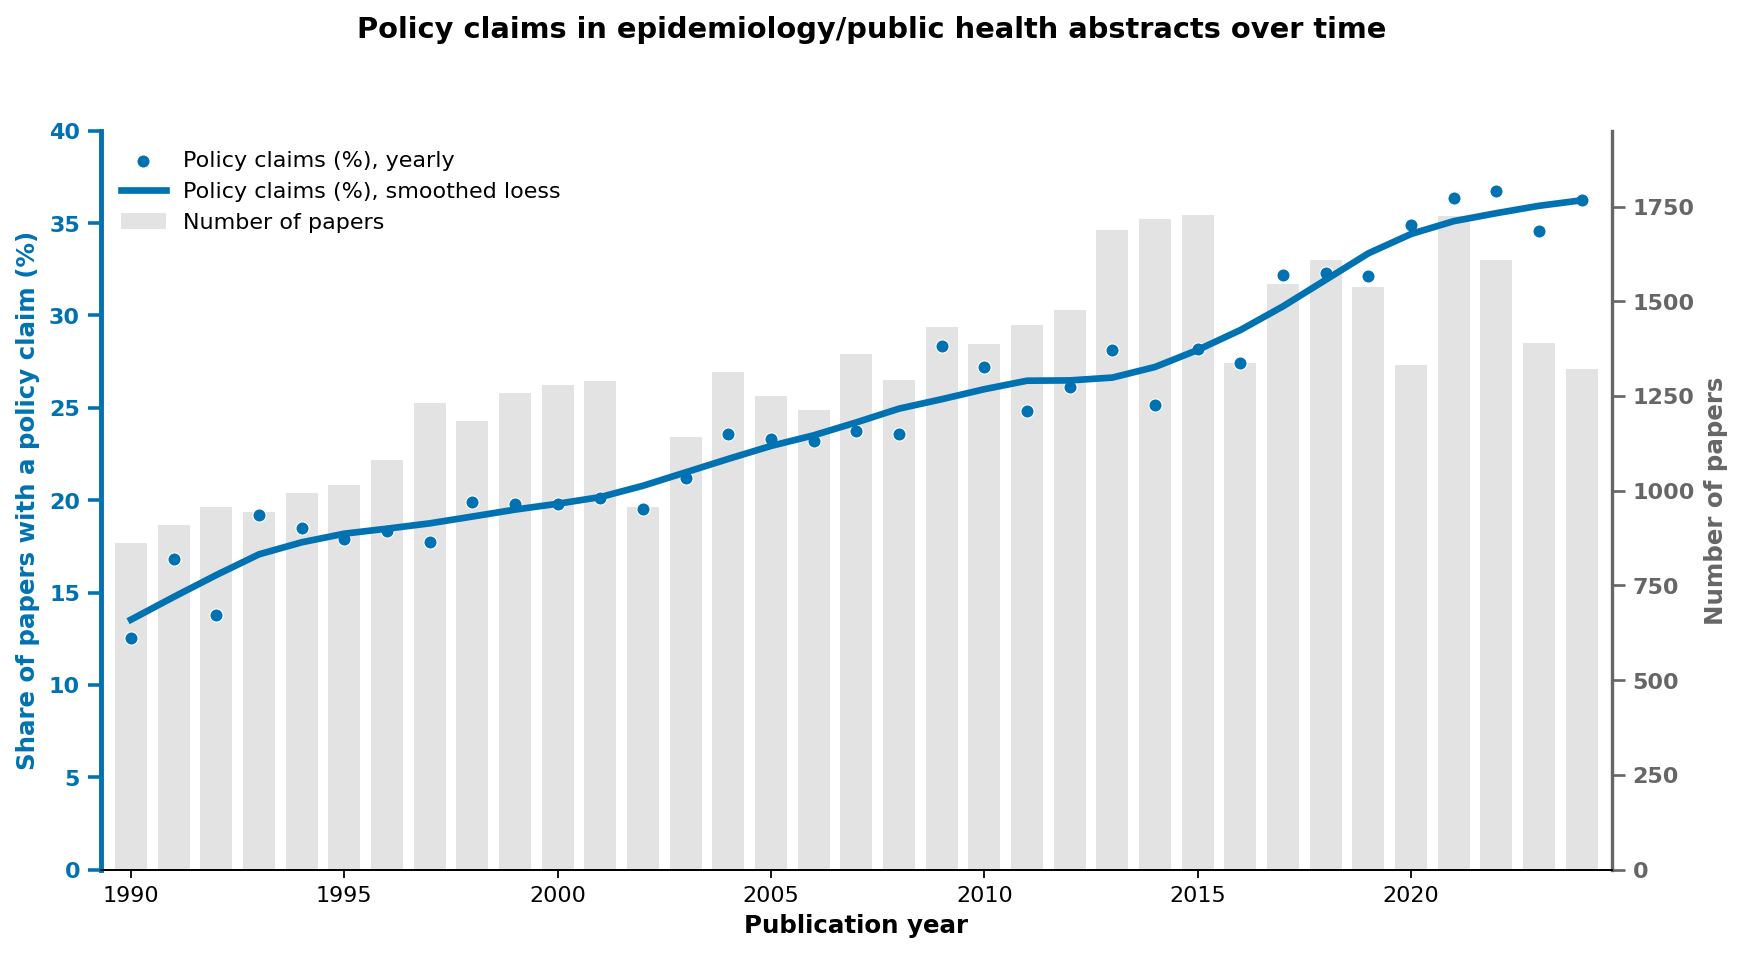

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- Configuration ----------------
FIGURE_DIR = Path("../figures")
YEAR_COL = "publication_year"
CLAIM_COL = "llm_policy_claim"
YEAR_MIN, YEAR_MAX = 1990, 2024
SAVE_PATH = "../figures/figure1_trend_policy_claims_loess.png"
LOESS_FRAC = 0.25

# ---------------- Prep ----------------
if YEAR_COL not in df.columns or CLAIM_COL not in df.columns:
    raise KeyError(f"Expected columns '{YEAR_COL}' and '{CLAIM_COL}' in df.")

work = df.copy()
work = work[work[YEAR_COL].notna() & work[CLAIM_COL].notna()].copy()

work[YEAR_COL] = pd.to_numeric(work[YEAR_COL], errors="coerce").astype("Int64")
work = work[work[YEAR_COL].notna()].copy()
work[YEAR_COL] = work[YEAR_COL].astype(int)

if work[CLAIM_COL].dtype != bool:
    work[CLAIM_COL] = work[CLAIM_COL].astype(str).str.strip().str.lower().map(
        {"true": True, "1": True, "t": True, "yes": True, "y": True,
         "false": False, "0": False, "f": False, "no": False, "n": False}
    ).fillna(work[CLAIM_COL].astype(bool))

work = work[(work[YEAR_COL] >= YEAR_MIN) & (work[YEAR_COL] <= YEAR_MAX)].copy()

# ---------------- Aggregate by year ----------------
agg = (work
       .groupby(YEAR_COL, dropna=False)[CLAIM_COL]
       .agg(n="count", n_claim="sum")
       .reset_index())

agg["pct_claim"] = np.where(agg["n"] > 0, 100 * agg["n_claim"] / agg["n"], np.nan)

# ---------------- LOESS smoothing ----------------
if agg[YEAR_COL].nunique() > 4:
    agg["pct_claim_smooth"] = lowess(
        endog=agg["pct_claim"],
        exog=agg[YEAR_COL],
        frac=LOESS_FRAC,
        return_sorted=False
    )
else:
    agg["pct_claim_smooth"] = np.nan

# ---------------- Plot ----------------
plt.style.use("default")
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=160)
ax2 = ax.twinx()

# --- FIX: BRING DOTS/LINES TO FRONT ---
# By default, ax2 (twinx) draws on top of ax. This forces ax to draw on top.
ax.set_zorder(10)
ax.patch.set_visible(False)  # Hide background of ax so the ax2 bars are visible underneath

# Colours
policy_color = "#0072B2"
count_color = "#666666"

# Clean spines
ax.grid(False)
ax2.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)

# Left y-axis strictly uses the exact blue shade
ax.spines["left"].set_color(policy_color)
ax.spines["left"].set_linewidth(2.2)
ax.yaxis.label.set_color(policy_color)
ax.yaxis.label.set_fontweight("medium")
ax.tick_params(axis="y", colors=policy_color, width=1.6, length=6)
ax.yaxis.get_offset_text().set_color(policy_color)

# Right y-axis grey, matching counts
ax2.spines["right"].set_color(count_color)
ax2.spines["right"].set_linewidth(1.5)
ax2.yaxis.label.set_color(count_color)
ax2.tick_params(axis="y", colors=count_color, width=1.2, length=6)
ax2.yaxis.get_offset_text().set_color(count_color)

# Bars: yearly counts (Draws perfectly underneath due to zorder fix above)
bars = ax2.bar(
    agg[YEAR_COL], agg["n"],
    alpha=0.18, width=0.75,
    color=count_color, edgecolor="none",
    label="Number of papers"
 )

# Dots (Restored white edge so the blue shade perfectly matches your image)
ax.scatter(
    agg[YEAR_COL], agg["pct_claim"],
    s=35, color=policy_color, edgecolors="white", linewidth=0.5,
    label="Policy claims (%), yearly"
 )

# LOESS line
ax.plot(
    agg[YEAR_COL], agg["pct_claim_smooth"],
    linewidth=3.0, color=policy_color,
    label="Policy claims (%), smoothed loess"
 )

# Labels
ax.set_xlabel("Publication year", fontsize=11, fontweight="bold")
ax.set_ylabel("Share of papers with a policy claim (%)", fontsize=11, color=policy_color, fontweight="bold")
ax2.set_ylabel("Number of papers", fontsize=11, color=count_color, fontweight="bold")

# Limits
ax.set_xlim(agg[YEAR_COL].min() - 0.7, agg[YEAR_COL].max() + 0.7)

# Precise Y-Axis bounding to match the image visually
ax.set_ylim(0, 40)
ax.set_yticks(np.arange(0, 45, 5))
ax2.set_ylim(0, 1950)
ax2.set_yticks(np.arange(0, 2000, 250))

for tick_label in ax.get_yticklabels():
    tick_label.set_fontweight("bold")

for tick_label in ax2.get_yticklabels():
    tick_label.set_fontweight("bold")

# Title
fig.suptitle(
    "Policy claims in epidemiology/public health abstracts over time",
    y=0.96, fontsize=13, fontweight="bold"
 )

# Legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig(SAVE_PATH, bbox_inches="tight", facecolor="white", dpi=300)
plt.show()

## Fig 1 with manual estimates

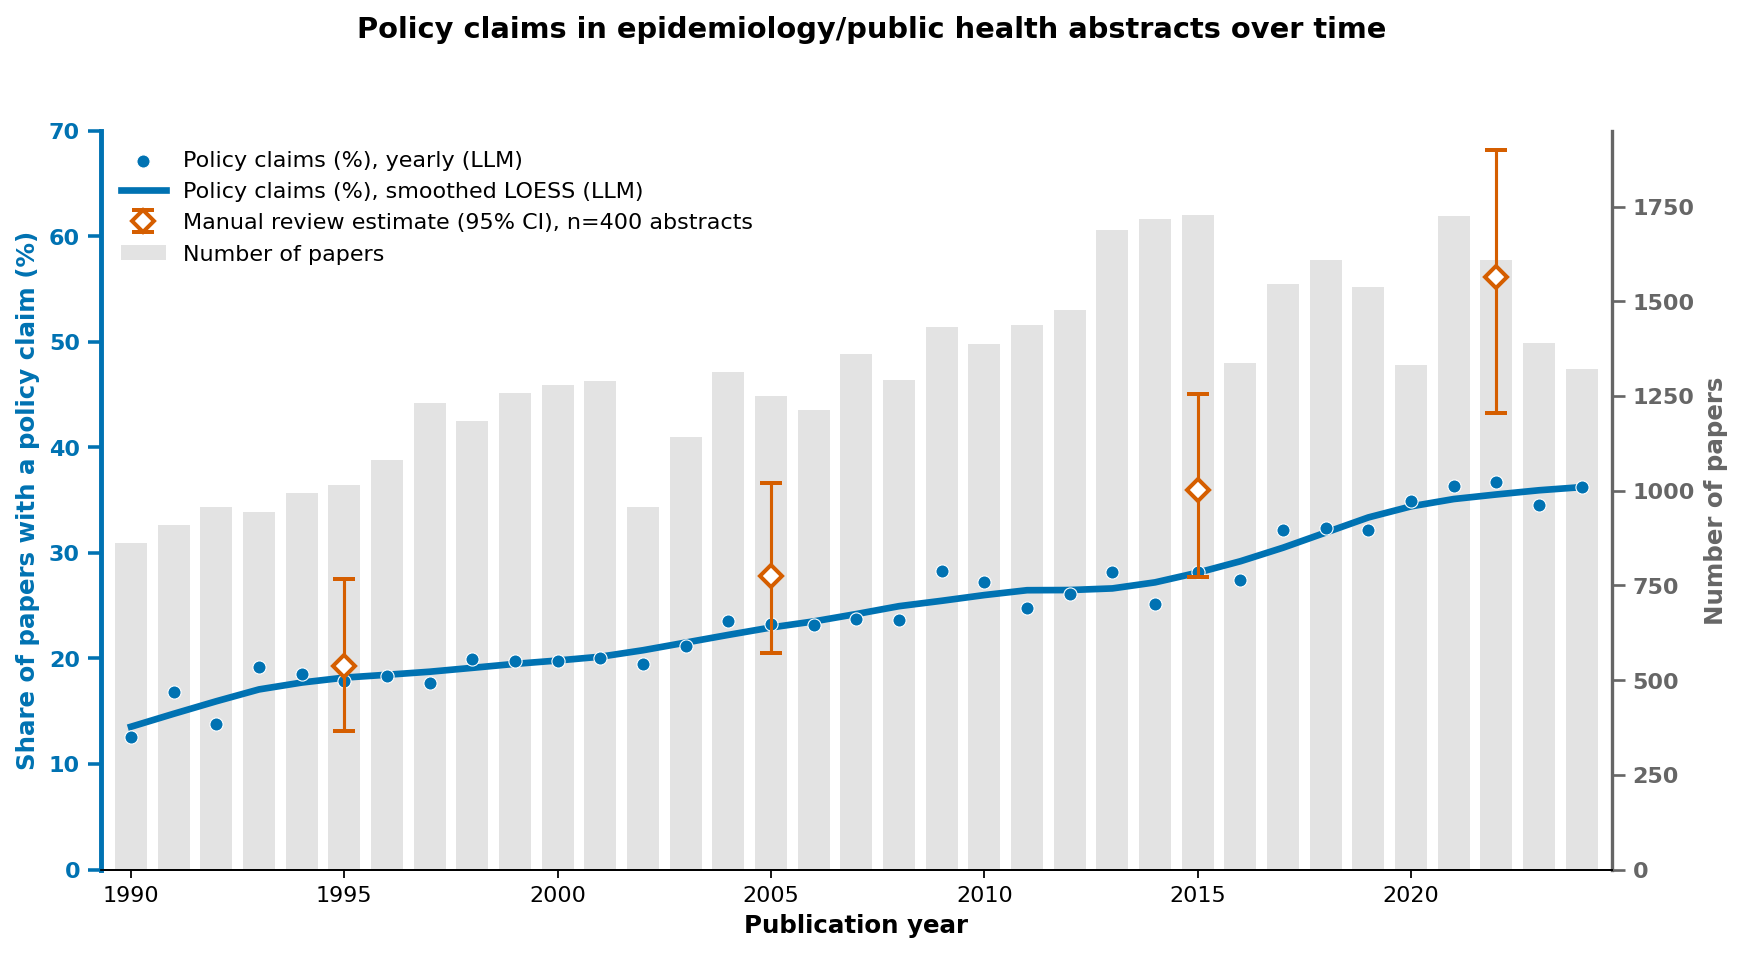

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- Configuration ----------------
FIGURE_DIR = Path("../figures")
YEAR_COL = "publication_year"
CLAIM_COL = "llm_policy_claim"
YEAR_MIN, YEAR_MAX = 1990, 2024
SAVE_PATH = "../figures/figure1_trend_policy_claims_loess.png"
LOESS_FRAC = 0.25

# ---------------- Prep ----------------
if YEAR_COL not in df.columns or CLAIM_COL not in df.columns:
    raise KeyError(f"Expected columns '{YEAR_COL}' and '{CLAIM_COL}' in df.")

work = df.copy()
work = work[work[YEAR_COL].notna() & work[CLAIM_COL].notna()].copy()

work[YEAR_COL] = pd.to_numeric(work[YEAR_COL], errors="coerce").astype("Int64")
work = work[work[YEAR_COL].notna()].copy()
work[YEAR_COL] = work[YEAR_COL].astype(int)

if work[CLAIM_COL].dtype != bool:
    work[CLAIM_COL] = work[CLAIM_COL].astype(str).str.strip().str.lower().map(
        {"true": True, "1": True, "t": True, "yes": True, "y": True,
         "false": False, "0": False, "f": False, "no": False, "n": False}
    ).fillna(work[CLAIM_COL].astype(bool))

work = work[(work[YEAR_COL] >= YEAR_MIN) & (work[YEAR_COL] <= YEAR_MAX)].copy()

# ---------------- Aggregate by year ----------------
agg = (work
       .groupby(YEAR_COL, dropna=False)[CLAIM_COL]
       .agg(n="count", n_claim="sum")
       .reset_index())

agg["pct_claim"] = np.where(agg["n"] > 0, 100 * agg["n_claim"] / agg["n"], np.nan)

# ---------------- LOESS smoothing ----------------
if agg[YEAR_COL].nunique() > 4:
    agg["pct_claim_smooth"] = lowess(
        endog=agg["pct_claim"],
        exog=agg[YEAR_COL],
        frac=LOESS_FRAC,
        return_sorted=False
    )
else:
    agg["pct_claim_smooth"] = np.nan

# ---------------- Manual 400-abstract estimates (Supplementary Table 8) ----------------
manual_estimates = pd.DataFrame([
    {"period": "1990-1999", "midyear": 1995, "n": 114, "k": 22, "est": 19.3, "lo": 13.1, "hi": 27.5},
    {"period": "2000-2009", "midyear": 2005, "n": 115, "k": 32, "est": 27.8, "lo": 20.5, "hi": 36.6},
    {"period": "2010-2019", "midyear": 2015, "n": 114, "k": 41, "est": 36.0, "lo": 27.7, "hi": 45.1},
    {"period": "2020-2024", "midyear": 2022, "n": 57,  "k": 32, "est": 56.1, "lo": 43.3, "hi": 68.2},
])
manual_yerr = np.vstack([
    manual_estimates["est"] - manual_estimates["lo"],
    manual_estimates["hi"] - manual_estimates["est"],
])

# ---------------- Plot ----------------
plt.style.use("default")
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=160)
ax2 = ax.twinx()

# --- FIX: BRING DOTS/LINES TO FRONT ---
ax.set_zorder(10)
ax.patch.set_visible(False)

# Colours
policy_color = "#0072B2"
count_color = "#666666"
manual_color = "#D55E00"   # dark orange — colorblind-safe contrast to the blue

# Clean spines
ax.grid(False)
ax2.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)

# Left y-axis strictly uses the exact blue shade
ax.spines["left"].set_color(policy_color)
ax.spines["left"].set_linewidth(2.2)
ax.yaxis.label.set_color(policy_color)
ax.yaxis.label.set_fontweight("medium")
ax.tick_params(axis="y", colors=policy_color, width=1.6, length=6)
ax.yaxis.get_offset_text().set_color(policy_color)

# Right y-axis grey, matching counts
ax2.spines["right"].set_color(count_color)
ax2.spines["right"].set_linewidth(1.5)
ax2.yaxis.label.set_color(count_color)
ax2.tick_params(axis="y", colors=count_color, width=1.2, length=6)
ax2.yaxis.get_offset_text().set_color(count_color)

# Bars: yearly counts
bars = ax2.bar(
    agg[YEAR_COL], agg["n"],
    alpha=0.18, width=0.75,
    color=count_color, edgecolor="none",
    label="Number of papers"
)

# LLM yearly dots
ax.scatter(
    agg[YEAR_COL], agg["pct_claim"],
    s=35, color=policy_color, edgecolors="white", linewidth=0.5,
    label="Policy claims (%), yearly (LLM)",
    zorder=4,
)

# LOESS line
ax.plot(
    agg[YEAR_COL], agg["pct_claim_smooth"],
    linewidth=3.0, color=policy_color,
    label="Policy claims (%), smoothed LOESS (LLM)",
    zorder=3,
)

# Manual 400-abstract estimates with 95% CIs
ax.errorbar(
    manual_estimates["midyear"],
    manual_estimates["est"],
    yerr=manual_yerr,
    fmt="D",                    # diamond to distinguish from LLM circles
    color=manual_color,
    ecolor=manual_color,
    elinewidth=1.4,
    capsize=5,
    markersize=7,
    markerfacecolor="white",
    markeredgewidth=1.8,
    zorder=6,
    label="Manual review estimate (95% CI), n=400 abstracts",
)

# Labels
ax.set_xlabel("Publication year", fontsize=11, fontweight="bold")
ax.set_ylabel("Share of papers with a policy claim (%)", fontsize=11, color=policy_color, fontweight="bold")
ax2.set_ylabel("Number of papers", fontsize=11, color=count_color, fontweight="bold")

# Limits
ax.set_xlim(agg[YEAR_COL].min() - 0.7, agg[YEAR_COL].max() + 0.7)

# Y-axis bumped to 70 so the 2020-2024 manual CI upper bound (68.2) is visible
ax.set_ylim(0, 70)
ax.set_yticks(np.arange(0, 75, 10))
ax2.set_ylim(0, 1950)
ax2.set_yticks(np.arange(0, 2000, 250))

for tick_label in ax.get_yticklabels():
    tick_label.set_fontweight("bold")

for tick_label in ax2.get_yticklabels():
    tick_label.set_fontweight("bold")

# Title
fig.suptitle(
    "Policy claims in epidemiology/public health abstracts over time",
    y=0.96, fontsize=13, fontweight="bold"
)

# Legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig(SAVE_PATH, bbox_inches="tight", facecolor="white", dpi=300)
plt.show()

## Fig 2: Country comparison slopegraph

*Figure 2. Policy claims by country, 1990–2024*

/var/folders/jn/q49x_b756ws_66x7djlfvhs00000gp/T/ipykernel_47618/2641216403.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: np.nan if isinstance(x, str) and not x.replace('.', '', 1).isdigit() else x)


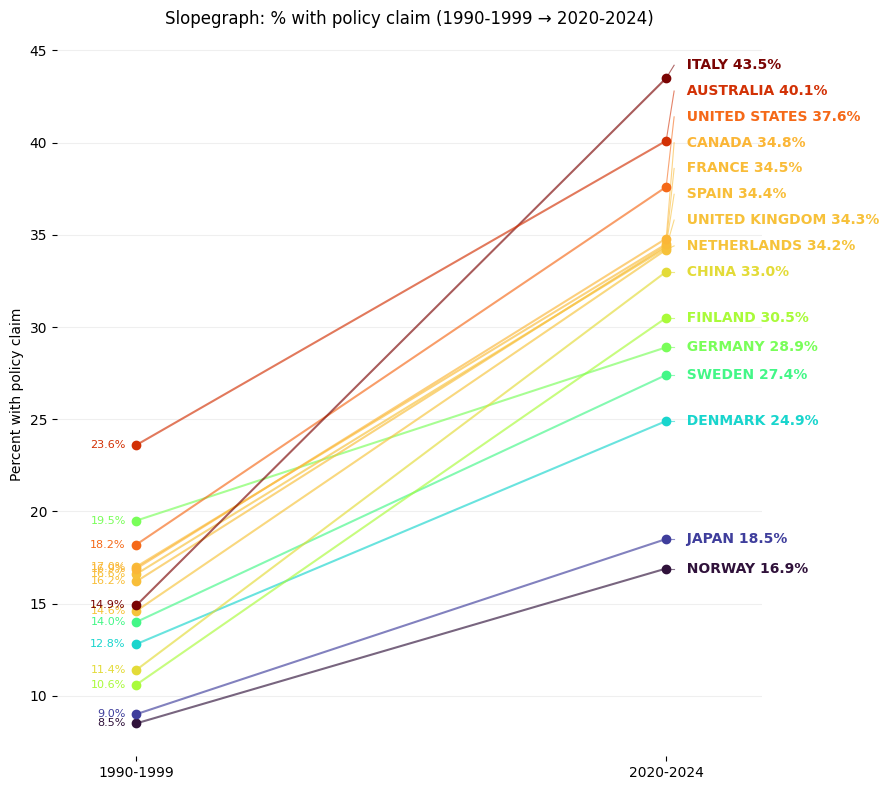

In [21]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

# --- Extract the country rows from your table1 ---
# (they start after the 'Countries' row)
country_start = row_names.index('Countries (first author), policy claim rate (%)') + 1
country_rows = row_names[country_start:]

# Make a new dataframe containing just those countries and numeric values
period_country = (
    table1.loc[country_rows, [c for c in table1.columns if c in periods.keys()]]
    .applymap(lambda x: np.nan if isinstance(x, str) and not x.replace('.', '', 1).isdigit() else x)
    .astype(float)
)

# Drop any rows or columns with missing values
period_country = period_country.dropna(how="all", axis=0).dropna(how="all", axis=1)

# --- Prepare columns for slopegraph ---
start_col = '1990-1999'
end_col = '2020-2024'

if start_col not in period_country.columns:
    start_col = period_country.columns[0]
if end_col not in period_country.columns:
    end_col = period_country.columns[-1]

data = period_country[[start_col, end_col]].copy()
data = data.dropna()

# Remove 'Unknown' or blank countries
data = data[~data.index.str.lower().str.contains('unknown')]

# --- Sort to reduce line crossings ---
order_score = 0.3 * data[start_col] + 0.7 * data[end_col]
data = data.loc[order_score.sort_values().index]

# --- Assign colors based on END value ---
end_values = data[end_col].values
norm_values = (end_values - end_values.min()) / (end_values.max() - end_values.min())
colors = cm.turbo(norm_values)
country_colors = dict(zip(data.index, colors))

# --- Compute non-overlapping y label positions ---
y_end_true = data[end_col].to_numpy(dtype=float)
min_gap = 1.4  # label spacing in percentage points
idx = np.argsort(y_end_true)
y_lab = y_end_true.copy()
for i in range(1, len(idx)):
    j, k = idx[i], idx[i-1]
    if y_lab[j] - y_lab[k] < min_gap:
        y_lab[j] = y_lab[k] + min_gap

y_label_pos = dict(zip(data.index[idx], y_lab[idx]))

y_end_true = data[end_col].to_numpy(dtype=float)
min_gap_right = 1.4
idxR = np.argsort(y_end_true)
y_lab_right = y_end_true.copy()
for i in range(1, len(idxR)):
    j, k = idxR[i], idxR[i-1]
    if y_lab_right[j] - y_lab_right[k] < min_gap_right:
        y_lab_right[j] = y_lab_right[k] + min_gap_right
y_label_pos_right = dict(zip(data.index[idxR], y_lab_right[idxR]))

# --- Plot the slopegraph ---
fig_h = max(8, 0.18 * len(data))
fig, ax = plt.subplots(figsize=(9, fig_h))
x0, x1 = 0.0, 1.0

for cty, row in data.iterrows():
    y0, y1 = float(row[start_col]), float(row[end_col])
    y1_lab = float(y_label_pos[cty])
    color = country_colors[cty]

    # line and points
    ax.plot([x0, x1], [y0, y1], linewidth=1.5, alpha=0.65, color=color)
    ax.scatter([x0, x1], [y0, y1], s=36, zorder=3, color=color)

    # text labels - LEFT SIDE NOW USES SAME COLOR
    ax.text(x0 - 0.02, y0, f"{y0:.1f}%", ha="right", va="center", fontsize=8, color=color)
    ax.plot([x1, x1 + 0.015], [y1, y1_lab], linewidth=0.8, alpha=0.6, color=color)
    ax.text(x1 + 0.02, y1_lab, f"{cty.upper()} {y1:.1f}%", ha="left", va="center",
            fontsize=10, fontfamily="sans-serif", fontweight="bold", color=color)

# Cosmetics
ax.set_xlim(-0.15, 1.18)
ax.set_xticks([x0, x1])
ax.set_xticklabels([start_col, end_col])
ax.set_ylabel("Percent with policy claim")
ax.set_title(f"Slopegraph: % with policy claim ({start_col} → {end_col})")
ax.grid(axis='y', alpha=0.2, linewidth=0.8)
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure2_slopegraph_policy_claims.png")
plt.show()

## Fig 3: Policy claims by journal (absolute and relative)

*Figure 3. Policy claims by journal: absolute counts (top) and relative percentage (bottom)*

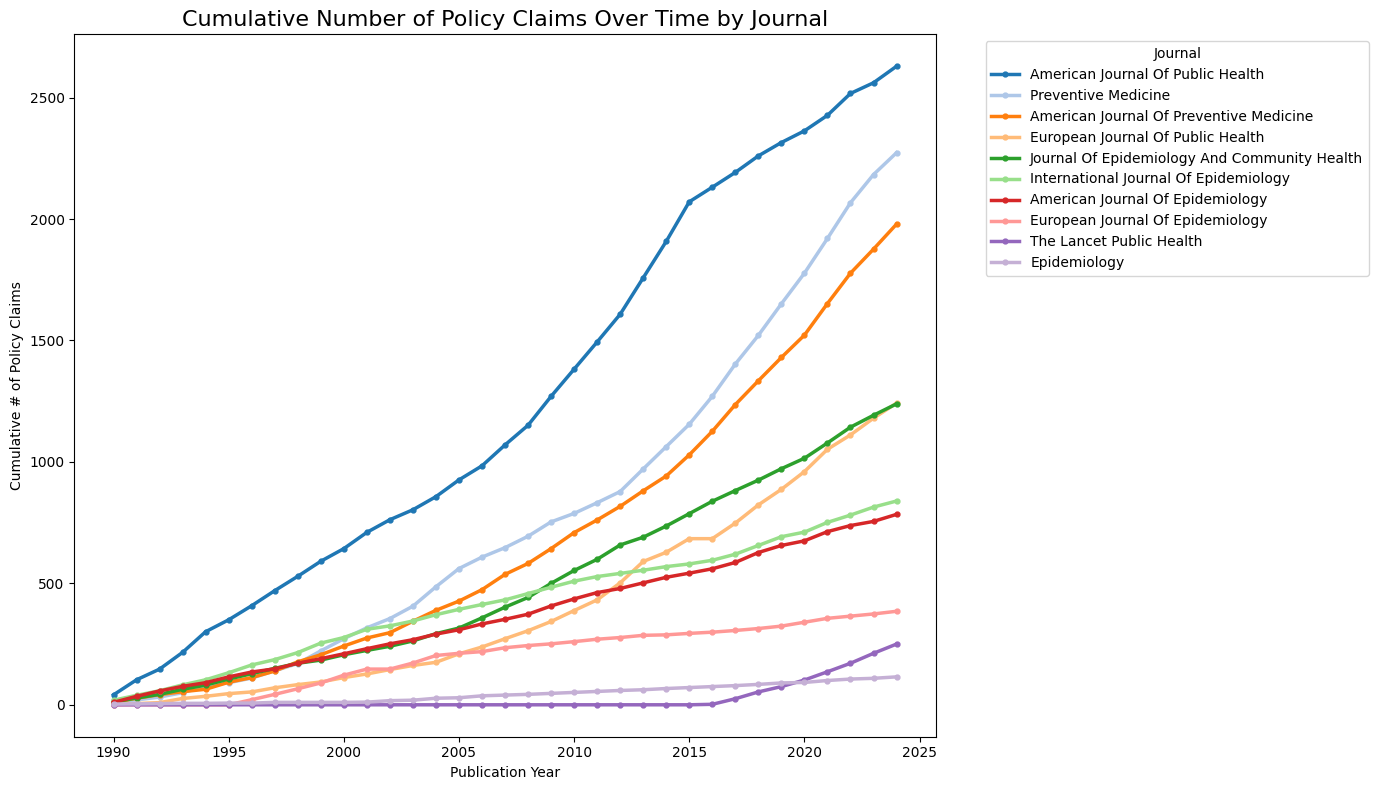

In [22]:
# TOP - Absolute Trends

# This plot shows the total count of policy claims accumulating over time for each of the top journals. 
# This is useful for seeing which journals have produced the largest absolute number of claims. We will plot the top 15 journals to keep the visualization clean.

# Group by year and journal, count claims, and then calculate the cumulative sum for all journals
cumulative_counts = (
    df.groupby([YEAR_COLUMN, JOURNAL_COLUMN])['claim']
    .sum()
    .unstack(fill_value=0)
    .cumsum()
)

# Sort columns (journals) by their final cumulative value descending
final_order = cumulative_counts.iloc[-1].sort_values(ascending=False).index
cumulative_counts = cumulative_counts[final_order]

palette = (sns.color_palette("tab20", n_colors=len(final_order))
           if len(final_order) <= 20 else sns.color_palette("hls", n_colors=len(final_order)))
journal_colors = dict(zip(final_order, palette))

# Create the plot
plt.figure(figsize=(14, max(8, 0.4*len(final_order))))
ax = cumulative_counts.plot(
    ax=plt.gca(),
    marker='o', linestyle='-',
    linewidth=2.5,            
    markersize=3.5,             
    color=[journal_colors[j] for j in final_order]
)

plt.title('Cumulative Number of Policy Claims Over Time by Journal', fontsize=16)
plt.ylabel('Cumulative # of Policy Claims')
plt.xlabel('Publication Year')
plt.legend(title='Journal', bbox_to_anchor=(1.05, 1), loc='upper left', labels=final_order)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "figure3_top_cumulative_absolute_by_journal.png")
plt.show() 


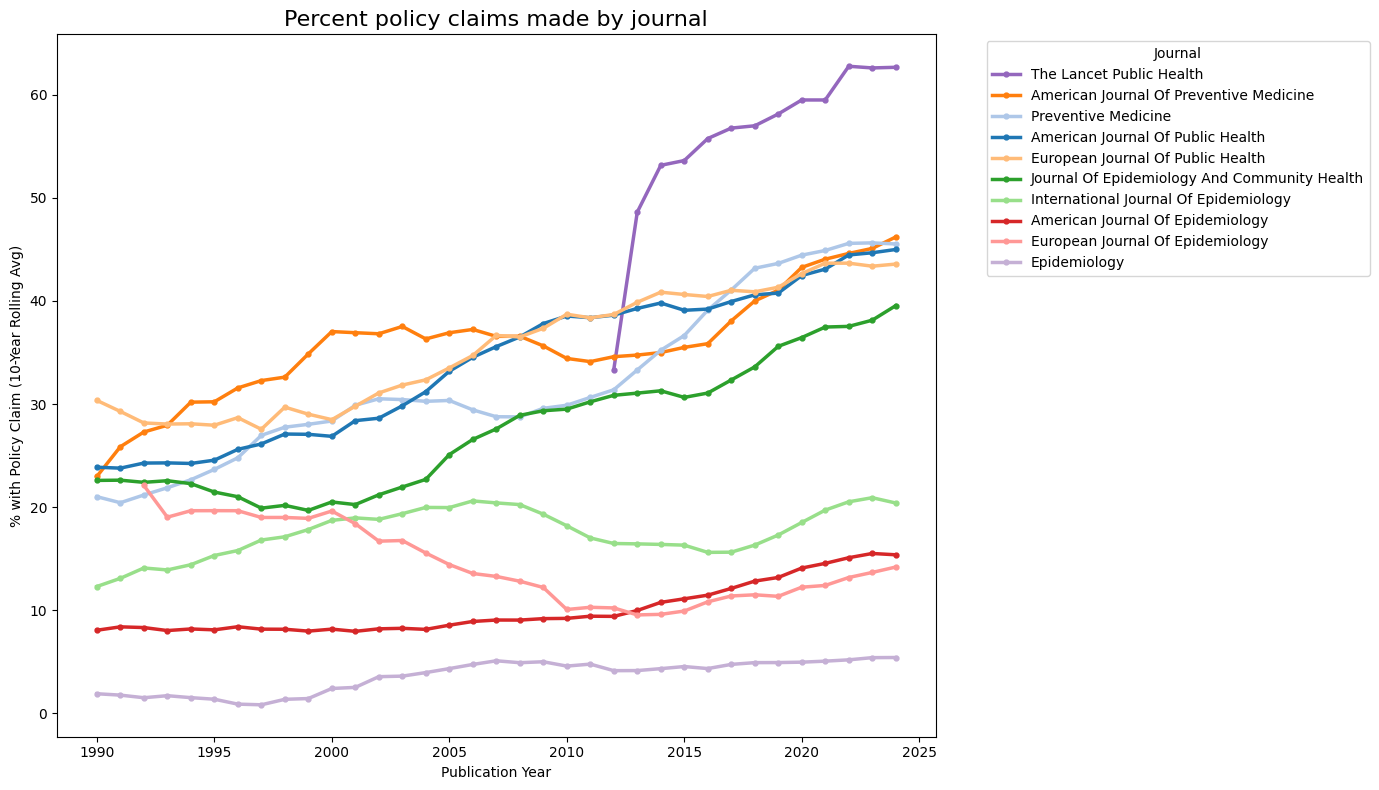

In [23]:
# BOTTOM  - Relative Trends: Percentage (%) of Claims per Year

# This plot shows the annual percentage of articles with policy claims. 
# This view is great for spotting year-to-year variability and recent changes in a journal's focus.

# Mean claim rate by journal and year (%)
yearly_percent_df = (
    df.groupby([YEAR_COLUMN, JOURNAL_COLUMN])['claim']
      .mean()
      .mul(100)
      .reset_index(name='percent_claim')
)

# 10 year centered rolling average
pivoted_df = yearly_percent_df.pivot(index=YEAR_COLUMN, columns=JOURNAL_COLUMN, values='percent_claim')

# ensure a continuous year index
year_idx = pd.RangeIndex(pivoted_df.index.min(), pivoted_df.index.max() + 1)
pivoted_df = pivoted_df.reindex(year_idx)

rolling_avg_df = pivoted_df.rolling(window=10, min_periods=1, center=True).mean()

# Order journals by their 2024 values (highest to lowest)
if 2024 in rolling_avg_df.index:
    values_2024 = rolling_avg_df.loc[2024].dropna().sort_values(ascending=False)
    legend_order = values_2024.index.tolist()
else:
    # fallback to last year if 2024 not available
    values_last = rolling_avg_df.iloc[-1].dropna().sort_values(ascending=False)
    legend_order = values_last.index.tolist()

# Reorder columns
rolling_avg_df = rolling_avg_df[legend_order]

# Plot with pandas/matplotlib to keep style consistent with the cumulative figure
plt.figure(figsize=(14, max(8, 0.4*len(legend_order))))
ax = rolling_avg_df.plot(
    ax=plt.gca(),
    marker='o', linestyle='-',
    linewidth=2.5,
    markersize=3.5,
    color=[journal_colors[j] for j in legend_order]
)

plt.title('Percent policy claims made by journal', fontsize=16)
plt.ylabel('% with Policy Claim (10-Year Rolling Avg)')
plt.xlabel('Publication Year')
plt.legend(title='Journal', bbox_to_anchor=(1.05, 1), loc='upper left', labels=legend_order)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "figure3_bottom_yearly_percent_by_journal_smoothed.png")
plt.show()



## Fig 4: Policy claims by study design

*Policy claim rates by study design (upper and right panels), and tabulations of study design by year (left)*


SUMMARY TABLES

--- Main Results: Combined Method (Strict with Keyword Fallback) ---
Total articles classified: 15075 / 45807
Excluded 30732 articles (67.1%)
      study_design_group  policy_claim_pct  n_articles
            Experimental         13.794773        2066
      Quasi-experimental         25.834543         689
                  Cohort         20.229853        7222
         Cross-sectional         36.857708        2024
Ecological / Time-series         26.692456         517
            Case-control          9.897331        2435
             Qualitative         46.721311         122


--- Sensitivity Analysis: Strict (Title/Abstract) vs. Keywords ---
Strict method classified 13748 articles. Keyword method classified 3774 articles.
      study_design_group Strict (Title/Abstract)       Keywords
            Experimental          13.8% (n=1828)  11.9% (n=606)
      Quasi-experimental           25.8% (n=683)  13.7% (n=102)
                  Cohort          21.3% (n=6493) 11.8% (n=

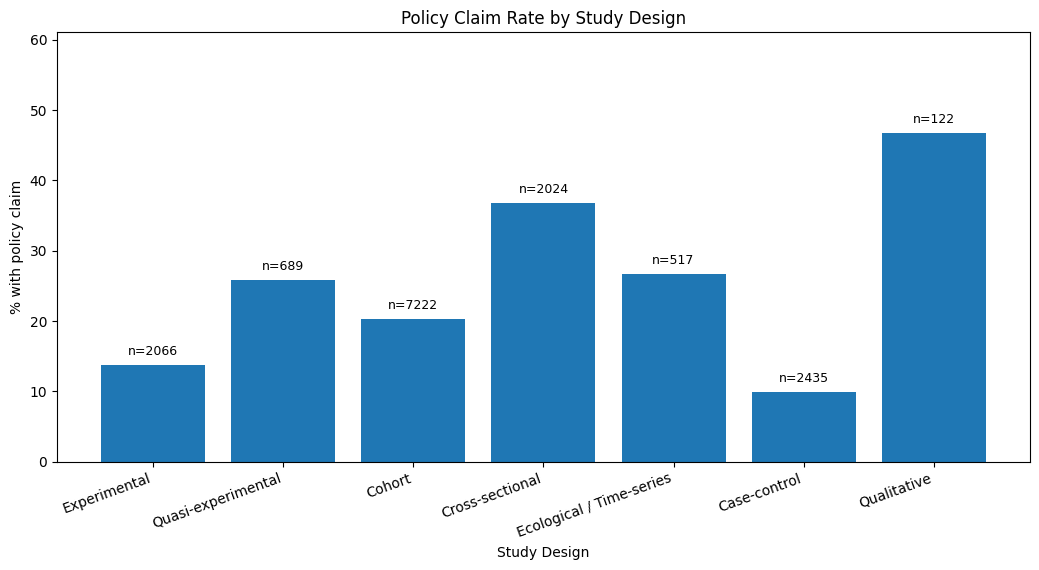

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# design_strict, design_keywords, and design_combined are already computed
# by 5_add_study_design_and_topics.py and loaded once above from ANALYSIS_DATA_FILE.
# No re-derivation needed here.

df = df[df['llm_policy_claim'].notna()].copy()
df['llm_policy_claim'] = df['llm_policy_claim'].astype(bool)

def summarize_and_prepare(df_in, design_col_name):
    df_filtered = df_in[df_in[design_col_name] != 'Other/None'].copy()
    summary = (
        df_filtered.groupby(design_col_name)['llm_policy_claim']
        .agg(policy_claim_pct=lambda s: 100 * s.mean(), n_articles='size')
        .reset_index()
    )
    order = ['Experimental', 'Quasi-experimental', 'Cohort', 'Cross-sectional',
             'Ecological / Time-series', 'Case-control', 'Qualitative']
    summary[design_col_name] = pd.Categorical(summary[design_col_name], categories=order, ordered=True)
    summary = summary.sort_values(design_col_name).rename(columns={design_col_name: 'study_design_group'})
    excluded_count = len(df_in) - len(df_filtered)
    return summary, excluded_count

summary_strict,    excluded_strict    = summarize_and_prepare(df, 'design_strict')
summary_keywords,  excluded_keywords  = summarize_and_prepare(df, 'design_keywords')
summary_combined,  excluded_combined  = summarize_and_prepare(df, 'design_combined')

# --- Plot ---
plt.figure(figsize=(10.5, 5.8))
x = np.arange(len(summary_combined))
y = summary_combined['policy_claim_pct'].values
labels = summary_combined['study_design_group'].astype(str).tolist()

plt.bar(x, y)
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel('% with policy claim')
plt.xlabel('Study Design')
plt.title('Policy Claim Rate by Study Design')
plt.grid(False)

for xi, yi, n in zip(x, y, summary_combined['n_articles'].values):
    pad = max(1, 0.02 * (max(y) if len(y) and max(y) > 0 else 50))
    plt.text(xi, yi + pad, f"n={int(n)}", ha='center', va='bottom', fontsize=9)

plt.ylim(0, (max(y) if len(y) else 0) * 1.20 + 5)
plt.tight_layout()

# --- Tables ---
print('\n' + '='*80)
print('SUMMARY TABLES')
print('='*80)

print('\n--- Main Results: Combined Method (Strict with Keyword Fallback) ---')
print(f"Total articles classified: {summary_combined['n_articles'].sum()} / {len(df)}")
print(f"Excluded {excluded_combined} articles ({excluded_combined/len(df)*100:.1f}%)")
print(summary_combined.to_string(index=False))

print('\n\n--- Sensitivity Analysis: Strict (Title/Abstract) vs. Keywords ---')
comparison_table = pd.merge(summary_strict, summary_keywords, on='study_design_group',
                             how='outer', suffixes=('_strict', '_keywords'))
numeric_cols = comparison_table.columns.drop('study_design_group')
comparison_table[numeric_cols] = comparison_table[numeric_cols].fillna(0)
comparison_table['Strict (Title/Abstract)'] = comparison_table.apply(
    lambda row: f"{row['policy_claim_pct_strict']:.1f}% (n={int(row['n_articles_strict'])})", axis=1)
comparison_table['Keywords'] = comparison_table.apply(
    lambda row: f"{row['policy_claim_pct_keywords']:.1f}% (n={int(row['n_articles_keywords'])})", axis=1)
final_table = comparison_table[['study_design_group', 'Strict (Title/Abstract)', 'Keywords']]
print(f"Strict method classified {len(df) - excluded_strict} articles. "
      f"Keyword method classified {len(df) - excluded_keywords} articles.")
print(final_table.to_string(index=False))

plt.savefig(FIGURE_DIR / 'figure4_upper_policy_claim_rate_by_study_design.png')
plt.show()


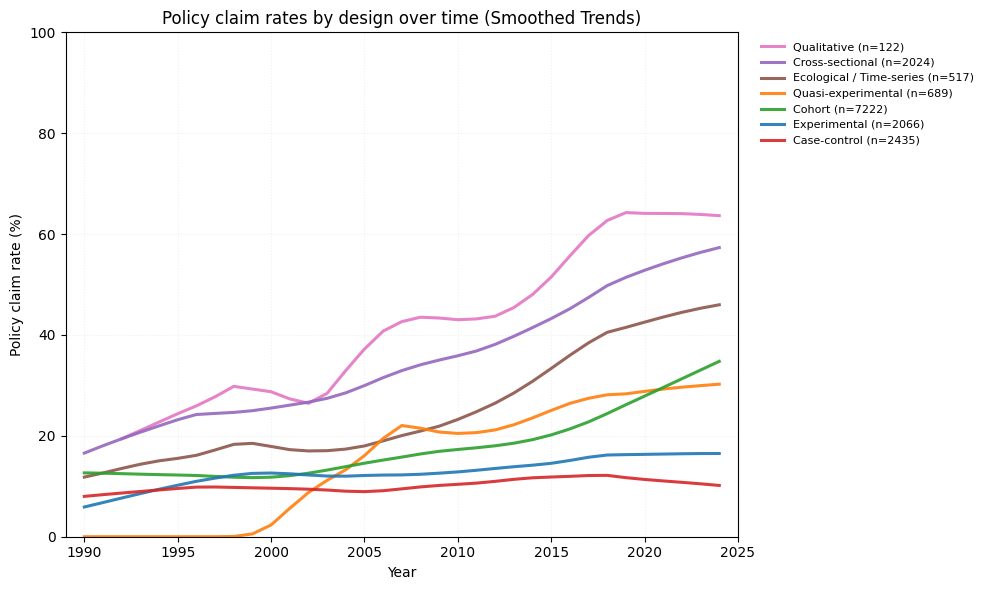

In [25]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

# Consistent colours for each study design category
fixed_color_map = {
    'Experimental':           '#1f77b4',
    'Quasi-experimental':     '#ff7f0e',
    'Cohort':                 '#2ca02c',
    'Case-control':           '#d62728',
    'Cross-sectional':        '#9467bd',
    'Ecological / Time-series': '#8c564b',
    'Qualitative':            '#e377c2',
}

# Exclude 'Other/None' from these plots.
df_filtered = df[df['design_combined'] != 'Other/None'].copy()

YEAR_COL   = "publication_year"
DESIGN_COL = "design_combined"
CLAIM_COL  = "llm_policy_claim"


yearly_counts = (
    df_filtered.groupby([YEAR_COL, DESIGN_COL])
    .size().reset_index(name="n_articles")
)
yearly_rates = (
    df_filtered.groupby([YEAR_COL, DESIGN_COL])[CLAIM_COL]
    .mean().mul(100).reset_index(name="rate")
)

rates_p = yearly_rates.pivot(index=YEAR_COL, columns=DESIGN_COL, values="rate")
counts_p = yearly_counts.pivot(index=YEAR_COL, columns=DESIGN_COL, values="n_articles").fillna(0)

# legend/order by the most recent available rate
recent = {d: (rates_p[d].dropna().iloc[-1] if d in rates_p else -np.inf) for d in rates_p.columns}
ordered = sorted(recent, key=recent.get, reverse=True)

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 6))
for d in ordered:
    if d not in rates_p: 
        continue
    y = rates_p[d].dropna()
    if len(y) < 3:
        continue
    years = y.index.values
    vals  = y.values
    n_tot = counts_p[d].reindex(y.index).sum()

    try:
        frac = max(0.25, min(0.4, 15/len(y)))
        sm = lowess(vals, years, frac=frac, return_sorted=True)
        ax.plot(sm[:, 0], sm[:, 1], linewidth=2.2, alpha=0.9,
                color=fixed_color_map.get(d), label=f"{d} (n={int(n_tot)})")
    except Exception:
        ax.plot(years, vals, linewidth=1.8, alpha=0.85,
                color=fixed_color_map.get(d), label=f"{d} (n={int(n_tot)})")

ax.set_xlim(rates_p.index.min()-1, rates_p.index.max()+1)
ax.set_ylim(0, 100)
ax.set_xlabel("Year"); ax.set_ylabel("Policy claim rate (%)")
ax.set_title("Policy claim rates by design over time (Smoothed Trends)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8)
ax.grid(True, alpha=0.2, linestyle=":")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "figure4_right_panel_policy_claim_rates_by_design_over_time_smoothed.png")
plt.show() 

# --- Build 5-year band pivot for heatmap (cell 41) ---
PERIOD_BINS  = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
PERIOD_LABELS = ['1990-94','1995-99','2000-04','2005-09','2010-14','2015-19','2020-24']

tmp = df_filtered[[YEAR_COL, DESIGN_COL]].copy()
tmp['period'] = pd.cut(tmp[YEAR_COL], bins=PERIOD_BINS, labels=PERIOD_LABELS, right=False)
temporal_pivot = (
    tmp.groupby(['period', DESIGN_COL], observed=True)
    .size().unstack(fill_value=0)
)
available = [d for d in [
    'Experimental','Quasi-experimental','Cohort','Case-control',
    'Cross-sectional','Ecological / Time-series','Qualitative',
] if d in temporal_pivot.columns]

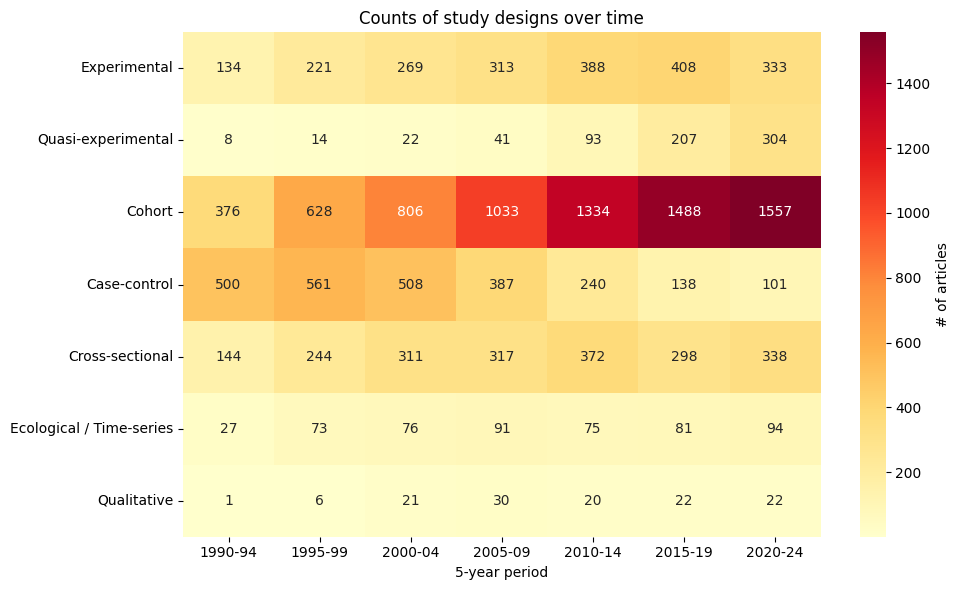

In [26]:
import seaborn as sns
ct = temporal_pivot[available].fillna(0)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ct.T, cmap="YlOrRd", annot=True, fmt=".0f", cbar_kws={"label":"# of articles"}, ax=ax)
ax.set_xlabel("5-year period"); ax.set_ylabel(""); ax.set_title("Counts of study designs over time")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure4_left_panel_counts_of_study_design_over_time_heatmap.png")
plt.show() 

## Fig 5: Policy claims by keyword/topic


TABLE 1: MOST COMMON KEYWORDS (Left Panel)
               Keyword  Total Papers  Policy Claims  No Policy Claims  Policy Claim Rate (%)
               Tobacco          1938            507              1431                   26.2
             Mortality          1674            265              1409                   15.8
     Physical Activity          1531            388              1143                   25.3
               Obesity          1271            284               987                   22.3
          Epidemiology          1214            265               949                   21.8
          Risk Factors          1162            215               947                   18.5
Cardiovascular Disease          1096            170               926                   15.5
        Cohort Studies          1001             96               905                    9.6
 Epidemiologic Methods           843             33               810                    3.9
             Pregnancy    

/var/folders/jn/q49x_b756ws_66x7djlfvhs00000gp/T/ipykernel_47618/3727953271.py:310: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


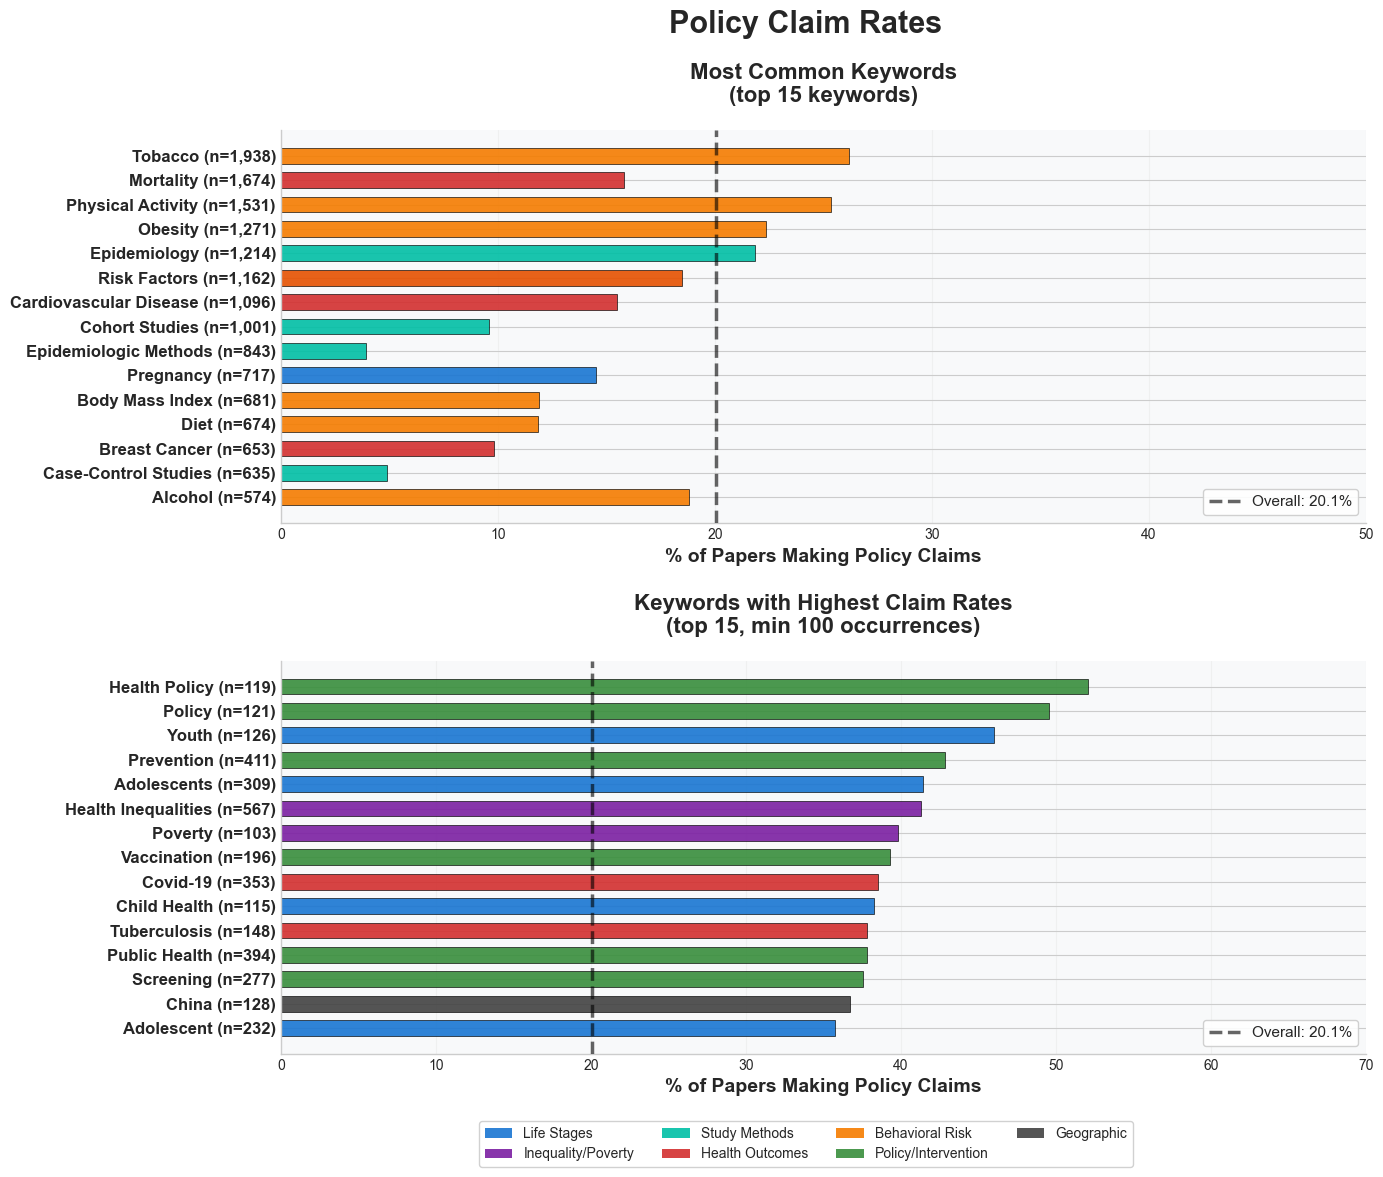

In [27]:
# Keyword Analysis and Visualization
# Keyword Analysis and Visualization (Optimised Colours)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import re
import pandas as pd
from matplotlib.patches import Patch

# --- PLOT SETUP ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(14, 12))  
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.35)  
axes = [fig.add_subplot(gs[i, 0]) for i in range(2)]
fig.suptitle('Policy Claim Rates', fontsize=22, fontweight='bold', y=0.98)

# --- KEYWORD PROCESSING ---
def process_keywords(keyword_data):
    """Extract and clean keywords from semicolon-separated string or list."""
    if isinstance(keyword_data, (list, tuple)):
        parts = keyword_data
    elif pd.isna(keyword_data):
        return []
    else:
        s = str(keyword_data).strip()
        if s in ('', '[]', '[ ]'):
            return []
        parts = [k.strip().strip("'\" ") for k in s.split(';')]
    return [k.lower().strip() for k in parts if k.strip() and len(k.strip()) > 1]


# --- CONSOLIDATION MAPPING ---
keyword_mapping = {
    # Health inequalities cluster
    'health inequalities': 'health inequalities',
    'health disparities': 'health inequalities',
    'disparities': 'health inequalities',
    'social inequalities': 'health inequalities',
    'inequalities': 'health inequalities',
    'healthcare disparities': 'health inequalities',

    # Tobacco cluster (under Behavioral Risk)
    'tobacco use': 'tobacco',
    'tobacco control': 'tobacco',
    'smoking': 'tobacco',
    'cigarette smoking': 'tobacco',

    # Violence cluster
    'domestic violence': 'domestic violence',
    'intimate partner violence': 'domestic violence',
    'partner violence': 'domestic violence',
    'family violence': 'domestic violence',
    'spouse abuse': 'domestic violence',

    # Physical activity cluster
    'physical activity': 'physical activity',
    'exercise': 'physical activity',
    'motor activity': 'physical activity',

    # Obesity cluster
    'obesity': 'obesity',
    'overweight': 'obesity',

    # Cancer types
    'breast neoplasms': 'breast cancer',
    'breast cancer': 'breast cancer',
    'colorectal neoplasms': 'colorectal cancer',
    'colorectal cancer': 'colorectal cancer',
    'lung neoplasms': 'lung cancer',
    'lung cancer': 'lung cancer',
    'cervical cancer': 'cervical cancer',
    'cervical neoplasms': 'cervical cancer',

    # Cardiovascular
    'cardiovascular diseases': 'cardiovascular disease',
    'cardiovascular disease': 'cardiovascular disease',
    'heart disease': 'cardiovascular disease',
    'coronary disease': 'cardiovascular disease',

    # Diabetes
    'diabetes mellitus': 'diabetes',
    'diabetes': 'diabetes',

    # Mental health
    'mental health': 'mental health',
    'mental disorders': 'mental health',
    'depression': 'depression',
    'depressive disorder': 'depression',

    # Alcohol
    'alcohol drinking': 'alcohol',
    'alcoholism': 'alcohol',
    'alcohol': 'alcohol',
}

# --- OPTIMISED COLOUR SCHEME (Swapped life stages and study methods) ---
keyword_colors = {
    # Life stages – NOW Bright blue (was study methods color)
    'child': '#1976D2',
    'adolescent': '#1976D2',
    'adolescents': '#1976D2',
    'youth': '#1976D2',
    'pregnancy': '#1976D2',
    'aged': '#1976D2',
    'child health': '#1976D2',

    # Inequality/socioeconomic – Deep purple
    'health inequalities': '#7B1FA2',
    'poverty': '#7B1FA2',

    # Study methods – NOW Vibrant teal (was life stages color)
    'epidemiology': '#00BFA5',
    'cohort studies': '#00BFA5',
    'case-control studies': '#00BFA5',
    'epidemiologic methods': '#00BFA5',
    'cohort study': '#00BFA5',
    'surveillance': '#00BFA5',

    # Health outcomes – Bright red
    'mortality': '#D32F2F',
    'morbidity': '#D32F2F',
    'incidence': '#D32F2F',
    'cardiovascular disease': '#D32F2F',
    'diabetes': '#D32F2F',
    'breast cancer': '#D32F2F',
    'cervical cancer': '#D32F2F',
    'tuberculosis': '#D32F2F',
    'covid-19': '#D32F2F',

    # Behavioral risk – Orange
    'obesity': '#F57C00',
    'physical activity': '#F57C00',
    'diet': '#F57C00',
    'body mass index': '#F57C00',
    'tobacco': '#F57C00',
    'smoking': '#F57C00',
    'alcohol': '#F57C00',

    # Policy/intervention – Forest green
    'prevention': '#388E3C',
    'screening': '#388E3C',
    'vaccination': '#388E3C',
    'health policy': '#388E3C',
    'policy': '#388E3C',
    'public health': '#388E3C',

    # Geographic – Dark gray
    'china': '#424242',
    'europe': '#424242',
    'canada': '#424242',

    # Violence – Deep burgundy
    'violence': '#922b21',
    'domestic violence': '#922b21',

    # Risk – Dark amber
    'risk factors': '#E65100',
}

def get_keyword_color(keyword):
    """Return color for keyword based on theme, or default gray"""
    return keyword_colors.get(keyword.lower(), '#95a5a6')

def consolidate_keywords(keywords):
    """Apply keyword consolidation mapping"""
    consolidated = []
    for kw in keywords:
        mapped_kw = keyword_mapping.get(kw, kw)
        consolidated.append(mapped_kw)
    return consolidated

# --- APPLY PROCESSING ---
df['keywords_clean'] = df['keywords'].apply(process_keywords)
df['keywords_clean'] = df['keywords_clean'].apply(consolidate_keywords)
df['keyword_count'] = df['keywords_clean'].apply(len)
df_with_keywords = df[df['keyword_count'] > 0].copy()

policy_df = df_with_keywords[df_with_keywords['llm_policy_claim'] == 1].copy()
non_policy_df = df_with_keywords[df_with_keywords['llm_policy_claim'] == 0].copy()

# --- COUNTING ---
policy_keywords = [kw for keywords in policy_df['keywords_clean'] for kw in keywords]
non_policy_keywords = [kw for keywords in non_policy_df['keywords_clean'] for kw in keywords]
policy_counter = Counter(policy_keywords)
non_policy_counter = Counter(non_policy_keywords)

invalid_entries = ['', '[]', '[ ]', None]
for invalid in invalid_entries:
    policy_counter.pop(invalid, None)
    non_policy_counter.pop(invalid, None)

MIN_OCCURRENCES = 5
MIN_OCCURRENCES_MIDDLE = 100
policy_color = '#c0392b'
non_policy_color = '#2980b9'

# --- POLICY CLAIM RATE BY KEYWORD ---
top_n = 15
all_valid_keywords = {}
for keyword in set(list(policy_counter.keys()) + list(non_policy_counter.keys())):
    total = policy_counter.get(keyword, 0) + non_policy_counter.get(keyword, 0)
    if total >= MIN_OCCURRENCES:
        all_valid_keywords[keyword] = total

keyword_policy_rates = []
for keyword, total_count in all_valid_keywords.items():
    policy_count = policy_counter.get(keyword, 0)
    policy_rate = (policy_count / total_count) * 100
    keyword_policy_rates.append((keyword, policy_rate, total_count))

keyword_policy_rates.sort(key=lambda x: x[2], reverse=True)
top_keywords = keyword_policy_rates[:top_n]

# --- PLOT LEFT PANEL ---
if top_keywords:
    keywords, policy_rates, total_counts = zip(*top_keywords)
    y_pos = np.arange(len(keywords))
    colors = [get_keyword_color(kw) for kw in keywords]
    axes[0].barh(y_pos, policy_rates, height=0.65, color=colors,
                 alpha=0.9, edgecolor='black', linewidth=0.5)
    labels = [f"{kw.title()} (n={tc:,})" for kw, tc in zip(keywords, total_counts)]
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(labels, fontsize=12, fontweight='bold')
    axes[0].set_xlabel('% of Papers Making Policy Claims', fontsize=14, fontweight='bold')
    axes[0].set_title(f'Most Common Keywords\n(top {top_n} keywords)', fontsize=16, fontweight='bold', pad=20)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.2)
    axes[0].set_xlim(0, 50)

overall_policy_rate = (len(policy_df) / len(df_with_keywords)) * 100
axes[0].axvline(x=overall_policy_rate, color='black', linestyle='--',
                alpha=0.6, linewidth=2.5, label=f'Overall: {overall_policy_rate:.1f}%', zorder=10)
axes[0].legend(loc='lower right', fontsize=11, frameon=True, framealpha=0.9)

# --- RIGHT PANEL (Highest policy claim rates) ---
high_freq_keywords = {k: v for k, v in all_valid_keywords.items() if v >= MIN_OCCURRENCES_MIDDLE}
high_freq_rates = []
for keyword, total_count in high_freq_keywords.items():
    policy_count = policy_counter.get(keyword, 0)
    policy_rate = (policy_count / total_count) * 100
    high_freq_rates.append((keyword, policy_rate, total_count))

high_freq_rates.sort(key=lambda x: x[1], reverse=True)
top_by_rate = high_freq_rates[:top_n]

if top_by_rate:
    keywords, policy_rates, total_counts = zip(*top_by_rate)
    y_pos = np.arange(len(keywords))
    colors = [get_keyword_color(kw) for kw in keywords]
    axes[1].barh(y_pos, policy_rates, height=0.65, color=colors,
                 alpha=0.9, edgecolor='black', linewidth=0.5)
    labels = [f"{kw.title()} (n={tc:,})" for kw, tc in zip(keywords, total_counts)]
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(labels, fontsize=12,fontweight='bold')
    axes[1].set_xlabel('% of Papers Making Policy Claims', fontsize=14, fontweight='bold')
    axes[1].set_title(f'Keywords with Highest Claim Rates\n(top 15, min {MIN_OCCURRENCES_MIDDLE} occurrences)',
                      fontsize=16, fontweight='bold', pad=20)
    axes[1].axvline(x=overall_policy_rate, color='black', linestyle='--',
                    alpha=0.6, linewidth=2.5, label=f'Overall: {overall_policy_rate:.1f}%', zorder=10)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.2)
    axes[1].set_xlim(0, 70)
    axes[1].legend(loc='lower right', fontsize=11, frameon=True, framealpha=0.9)

# --- STYLE & LEGEND (Only show categories present in plots) ---
for ax in axes:
    ax.set_facecolor('#f8f9fa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Collect all keywords actually shown in both plots
shown_keywords = set()
if top_keywords:
    shown_keywords.update([kw for kw, _, _ in top_keywords])
if top_by_rate:
    shown_keywords.update([kw for kw, _, _ in top_by_rate])

# Determine which categories are present
categories_present = set()
category_map = {
    '#1976D2': 'Life Stages',
    '#7B1FA2': 'Inequality/Poverty',
    '#00BFA5': 'Study Methods',
    '#D32F2F': 'Health Outcomes',
    '#F57C00': 'Behavioral Risk',
    '#388E3C': 'Policy/Intervention',
    '#424242': 'Geographic',
    '#922b21': 'Violence',
}

for kw in shown_keywords:
    color = get_keyword_color(kw)
    if color in category_map:
        categories_present.add((color, category_map[color]))

# Sort to maintain consistent order
categories_present = sorted(categories_present, key=lambda x: list(category_map.values()).index(x[1]))

# Create legend with only present categories
legend_elements = [Patch(facecolor=color, label=label, alpha=0.9) 
                   for color, label in categories_present]

fig.legend(handles=legend_elements,
           loc='lower center',
           ncol=min(4, len(legend_elements)),
           fontsize=10, frameon=True, framealpha=0.9,
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 0.95]) 

# --- CREATE SUMMARY TABLES ---
# Left panel data (Most Common Keywords)
left_panel_data = []
for kw, rate, count in top_keywords:
    policy_count = policy_counter.get(kw, 0)
    non_policy_count = non_policy_counter.get(kw, 0)
    left_panel_data.append({
        'Keyword': kw.title(),
        'Total Papers': count,
        'Policy Claims': policy_count,
        'No Policy Claims': non_policy_count,
        'Policy Claim Rate (%)': round(rate, 1)
    })

# Right panel data (Highest Claim Rates)
right_panel_data = []
for kw, rate, count in top_by_rate:
    policy_count = policy_counter.get(kw, 0)
    non_policy_count = non_policy_counter.get(kw, 0)
    right_panel_data.append({
        'Keyword': kw.title(),
        'Total Papers': count,
        'Policy Claims': policy_count,
        'No Policy Claims': non_policy_count,
        'Policy Claim Rate (%)': round(rate, 1)
    })

# Create DataFrames
left_df = pd.DataFrame(left_panel_data)
right_df = pd.DataFrame(right_panel_data)

# --- DISPLAY TABLES ---
print("\n" + "="*90)
print("TABLE 1: MOST COMMON KEYWORDS (Left Panel)")
print("="*90)
print(left_df.to_string(index=False))

print("\n" + "="*90)
print(f"TABLE 2: KEYWORDS WITH HIGHEST POLICY CLAIM RATES (Right Panel, min {MIN_OCCURRENCES_MIDDLE} occurrences)")
print("="*90)
print(right_df.to_string(index=False))

# --- SUMMARY ---
print("\n" + "="*90)
print("KEY INSIGHTS FROM KEYWORD ANALYSIS")
print("="*90)
print(f"\nOverall policy claim rate: {overall_policy_rate:.1f}%")
print(f"Total papers with keywords: {len(df_with_keywords):,}")
print(f"Papers making policy claims: {len(policy_df):,}")
print(f"Papers not making policy claims: {len(non_policy_df):,}")
print(f"\nTop 5 keywords with highest policy claim rates (min {MIN_OCCURRENCES_MIDDLE} occurrences):")
for i, (kw, rate, count) in enumerate(high_freq_rates[:5], 1):
    print(f"  {i}. {kw}: {rate:.1f}% of {count} papers make policy claims")


plt.savefig(FIGURE_DIR / "figure5_policy_claim_rates_keywords.png")
plt.show() 
